In [61]:
#Import#

from cellpose import models, core, io, plot
from cellpose import train
from cellpose import metrics
import pickle, numpy as np
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import imageio.v2 as imageio
import os
import skimage.filters
from skimage.feature import peak_local_max
from skimage.measure import regionprops
from skimage import exposure
from skimage.measure import regionprops
from skimage.segmentation import watershed
from skimage.segmentation import mark_boundaries
from skimage import img_as_float
from skimage.filters import sobel
from skimage.feature import blob_dog
from skimage import data, color, filters, segmentation, measure, morphology
from scipy import ndimage as ndi
from scipy.spatial.distance import cdist
from scipy.spatial.distance import pdist
from scipy.ndimage import generate_binary_structure, binary_dilation
from scipy.spatial import Delaunay
from scipy.stats import qmc
import pandas as pd
from glob import glob
import cv2
import re
from collections import Counter


import time

In [2]:
#Data input from the User

folder_path = r'Y:\Group Members\Valentin Aubry\01_Data\Data_Andreas_single'  # The r in r'Example\Pathway' is very important to get the raw input


# Check if the folder is empty or even exists
if os.path.isdir(folder_path) == True:
    print("Folder Path exists")

    # Getting the list of directories
    dir = os.listdir(folder_path)
    
    # Checking if the list is empty or not
    if len(dir) == 0:
        print("Empty directory")
    else:
        print("Not empty directory")
else:
    print("Folder path not found")

Folder Path exists
Not empty directory


In [3]:
# Data Loading


# High Throughput Data Loading
Cy5_data = glob(os.path.join(folder_path, '*Cy5 SEM.tif'))
DAPI_data = glob(os.path.join(folder_path, '*DAPI SEM.tif'))
DAPI_mask_data = glob(os.path.join(folder_path, '*DAPI SEM_seg.npy'))
FITC_data = glob(os.path.join(folder_path, '*FITC SEM.tif'))
TRITC_data = glob(os.path.join(folder_path, '*TRITC SEM.tif'))


# Sorting the data in case it isn't yet
Cy5_data.sort()
DAPI_data.sort()
DAPI_mask_data.sort()
FITC_data.sort()
TRITC_data.sort()


# Displaying all the data that was loaded
for i in range (len(DAPI_data)):
    print(os.path.basename(Cy5_data[i]))
    print(os.path.basename(DAPI_data[i]))
    print(os.path.basename(DAPI_mask_data[i]))
    print(os.path.basename(FITC_data[i]))
    print(os.path.basename(TRITC_data[i]))





ATR2_24h--W00044--P00021--Z00000--T00000--Cy5 SEM.tif
ATR2_24h--W00044--P00021--Z00000--T00000--DAPI SEM.tif
ATR2_24h--W00044--P00021--Z00000--T00000--DAPI SEM_seg.npy
ATR2_24h--W00044--P00021--Z00000--T00000--FITC SEM.tif
ATR2_24h--W00044--P00021--Z00000--T00000--TRITC SEM.tif


In [4]:
# Loading Functions

# Function to check if a potential foci is X-times brighter than the immediate Background (preventing false positives)
def local_contrast(image, coordinates, bright_percentage, contrast_threshold=2.5):
    """
    Filter detected foci by comparing their intensity to local background.
    
    This function confirms foci as true positives only if they are significantly
    brighter than their immediate surroundings, reducing false positive detections
    from background noise or imaging artifacts.
    
    Parameters:
    -----------
    image : numpy.ndarray
        2D array of the fluorescence image (grayscale) where foci are detected.
        Typically a single channel (e.g., TRITC, FITC) image.
    
    coordinates : numpy.ndarray
        Array of shape (N, 2) containing (y, x) coordinates of potential foci
        detected by peak_local_max or similar detection methods.
    
    bright_percentage : int or float
        Percentile (0-100) used to define local background brightness.
        For example:
        - 50 compares to median brightness around the focus
        - 25 compares to dimmer regions (more stringent filtering)
        - 75 compares to brighter regions (less stringent filtering)
    
    contrast_threshold : float, optional (default=2.5)
        Minimum contrast ratio between focus and local background.
        Focus intensity must be > (local_background * contrast_threshold).
        Higher values = more stringent filtering (fewer false positives).
        Typical values: 1.5-3.0
    
    Returns:
    --------
    numpy.ndarray
        Array of shape (M, 2) containing confirmed foci coordinates where M <= N.
        Returns empty array of shape (0, 2) if no foci pass the contrast filter.
    
    Notes:
    ------
    - Uses an 11x11 pixel square (±5 pixels) around each potential focus
    - Edge cases are handled by clamping to image boundaries
    - Empty return is shaped (0, 2) for compatibility with downstream processing
    """
    confirmed_coords = []  #Empty array to store the filtered coordinates in later
    for i in coordinates:
        y, x = i   # Get the coordinates for each foci 
        y_min, y_max = max(0, y-6), min(image.shape[0], y+7)  #setting boudaries from y-5 to y+5(Y+6 gets excluded as upper border)
        x_min, x_max = max(0, x-6), min(image.shape[1], x+7)
        square = image[y_min:y_max, x_min:x_max]  #creating a square with the defined boudaries

        potential_foci = image[y, x]
        local_background = np.percentile(square, bright_percentage)  # Selects a pixel with the brightness in the defined percentage for comparison

        if potential_foci > local_background * contrast_threshold:  # If the potential foci is X-times brighter than the selected background, the foci is confirmed
            confirmed_coords.append(i)
            
    # returns the confirmed foci coordinates or if there are none creates an empty array to not crash the display below
    return np.array(confirmed_coords) if confirmed_coords else np.array([]).reshape(0, 2)





def save_dataframe_to_csv(df, folder_path, base_name, data_type):
    """
    Save a DataFrame to CSV with Excel-compatible formatting.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The dataframe to save
    folder_path : str
        Directory where file will be saved
    base_name : str
        Base filename (without extension)
    data_type : str
        Type of data being saved (e.g., 'foci', 'nucleus', 'cytoplasm')
    """
    filename = f"{folder_path}/{base_name}--{data_type}_DF_SEM.csv"
    
    # Write sep=, line for Excel compatibility
    with open(filename, 'w') as f:
        f.write('sep=,\n')
    
    # Write data with header
    df.to_csv(filename, mode='a', header=True, index=False)

Generated 256 valid parameter combinations
Min distance between samples: 0.2930
Mean distance: 32.4888


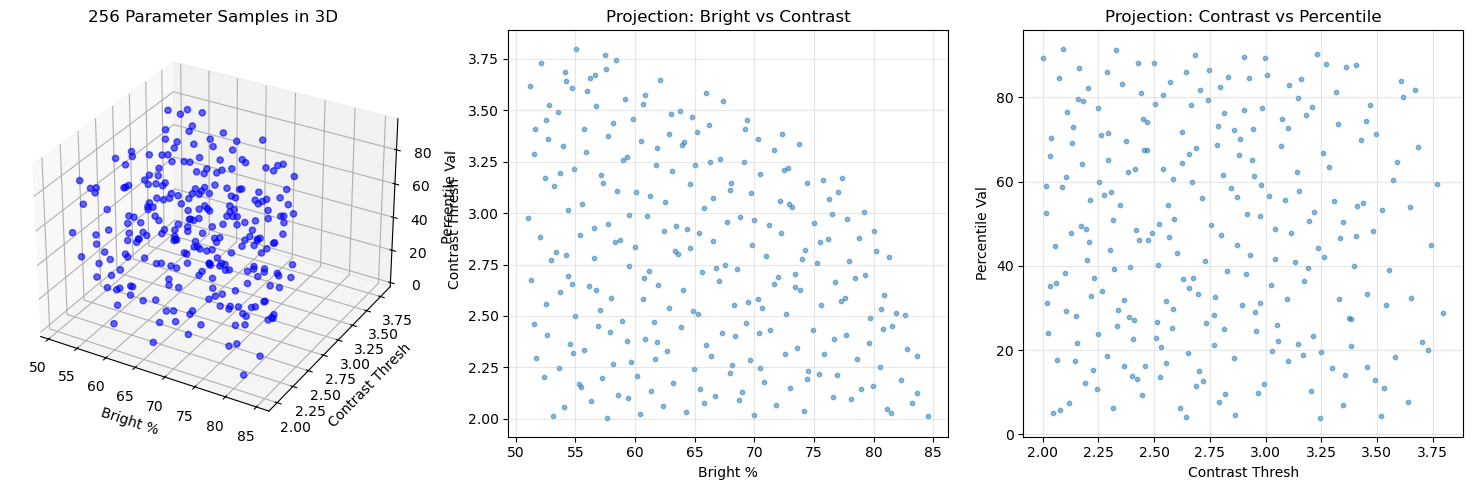

In [68]:
#load the convex hull and the bounding box parameters to iterate through the parameters
with open(r"Y:\Group Members\Valentin Aubry\01_Data\Parameters\Hull\valid_parameter_hull.pkl", "rb") as f:
    delaunay = pickle.load(f)
param_bounds = dict(np.load(r"Y:\Group Members\Valentin Aubry\01_Data\Parameters\Hull\parameter_bounds.npz"))


# Generate space-filling samples
n_parameter_samples = 256

# Use Sobol sequence (best space-filling)
sampler = qmc.Sobol(d=3, scramble=True)
unit_samples = sampler.random(n=n_parameter_samples * 10)  # Oversample

# Scale to parameter bounds
scaled_samples = qmc.scale(
    unit_samples,
    l_bounds=[param_bounds["bright_pct"][0], 
              param_bounds["contrast_thresh"][0], 
              param_bounds["percentile_val"][0]],
    u_bounds=[param_bounds["bright_pct"][1], 
              param_bounds["contrast_thresh"][1], 
              param_bounds["percentile_val"][1]]
)

# Keep only points inside hull
valid_param_samples = []
for point in scaled_samples:
    if in_hull([point])[0]:
        valid_param_samples.append(point)
        if len(valid_param_samples) >= n_parameter_samples:
            break

valid_param_samples = np.array(valid_param_samples)

# Verify coverage
from scipy.spatial.distance import pdist
distances = pdist(valid_param_samples)
print(f"Generated {len(valid_param_samples)} valid parameter combinations")
print(f"Min distance between samples: {np.min(distances):.4f}")
print(f"Mean distance: {np.mean(distances):.4f}")
visualize_parameter_sampling(valid_param_samples , param_bounds, delaunay)


=== Hull Acceptance Rate ===
Points tested: 512
Points inside hull: 384
Acceptance rate: 75.00%
✓ High acceptance rate - oversample by 2-3×

=== Per-Dimension Statistics ===

Inside Hull:
  Bright %: 51.2 - 85.2 (mean: 66.5)
  Contrast: 2.00 - 3.82 (mean: 2.73)
  Percentile: 3.8 - 91.8 (mean: 49.2)

Bounding Box:
  Bright %: 51.0 - 85.5
  Contrast: 2.00 - 3.84
  Percentile: 3.8 - 92.0

Estimated hull volume: ~75.0% of bounding box


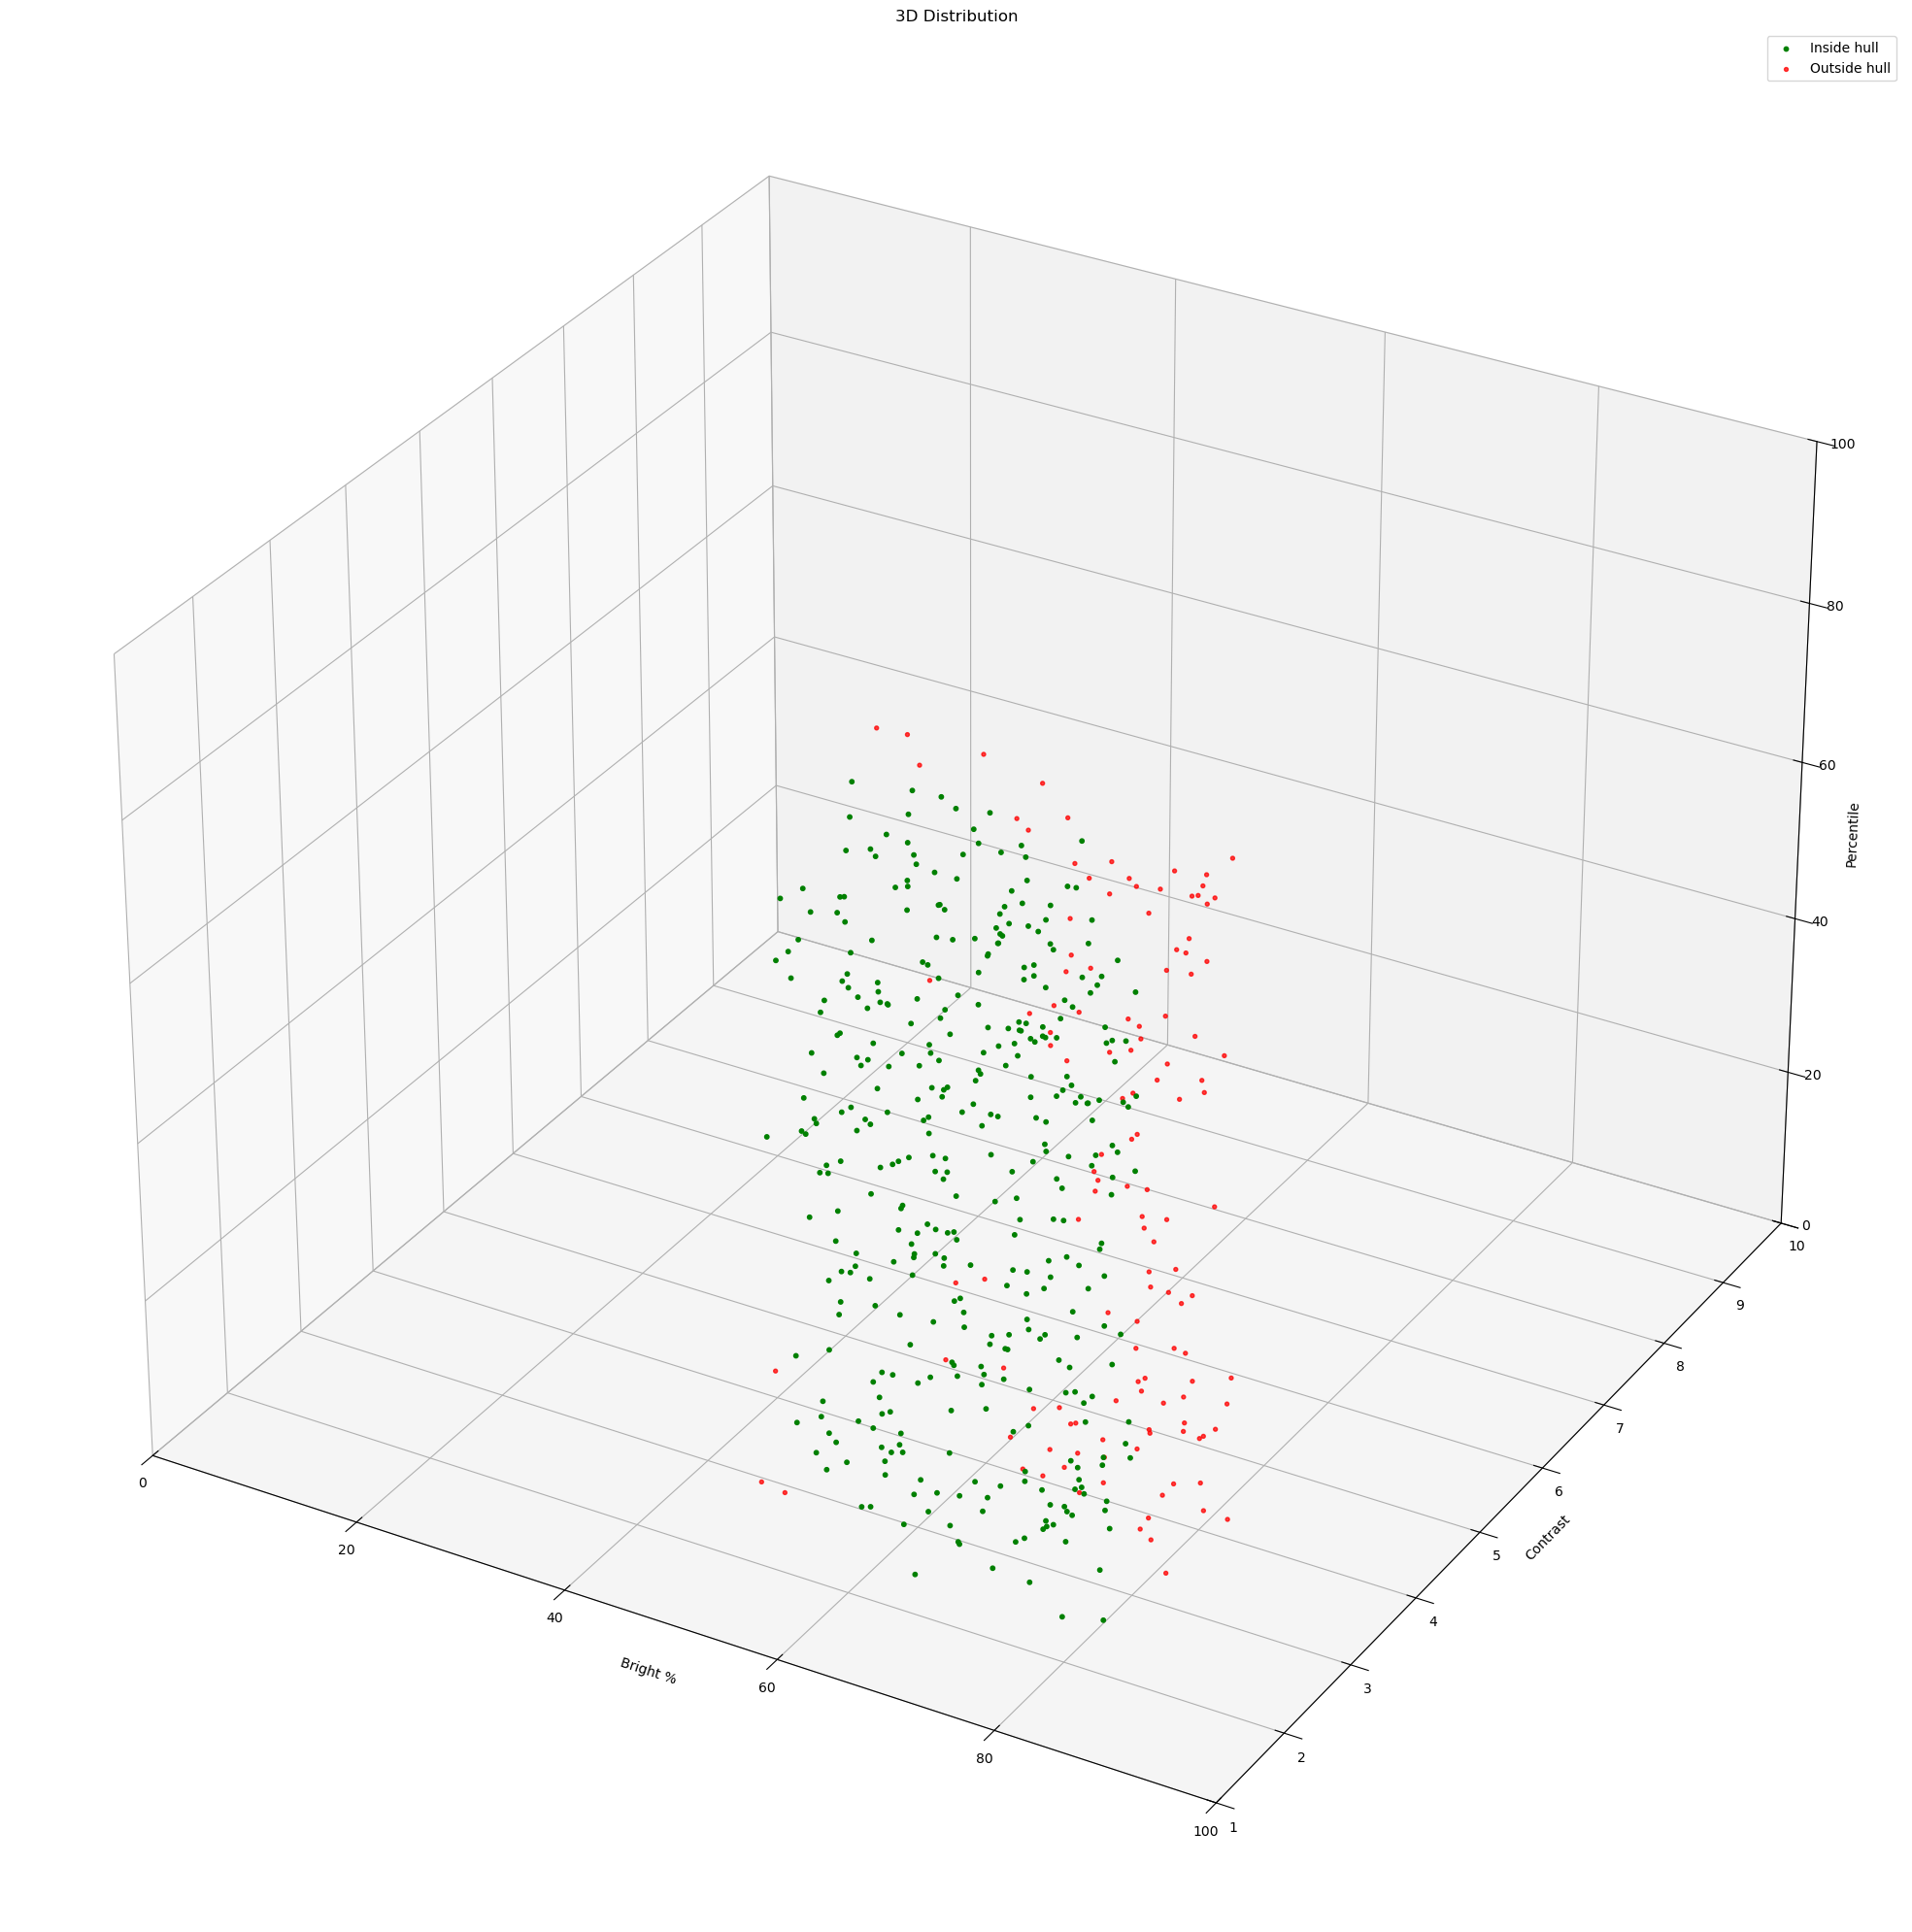

In [83]:
# After loading your hull and bounds
# Generate random points in bounding box
n_test = 512  # Test with 10k points
test_points = np.random.uniform(
    low=[param_bounds["bright_pct"][0], 
         param_bounds["contrast_thresh"][0], 
         param_bounds["percentile_val"][0]],
    high=[param_bounds["bright_pct"][1], 
          param_bounds["contrast_thresh"][1], 
          param_bounds["percentile_val"][1]],
    size=(n_test, 3)
)

# Check how many are inside hull
inside_hull = in_hull(test_points)
acceptance_rate = np.sum(inside_hull) / n_test * 100

print(f"\n=== Hull Acceptance Rate ===")
print(f"Points tested: {n_test}")
print(f"Points inside hull: {np.sum(inside_hull)}")
print(f"Acceptance rate: {acceptance_rate:.2f}%")

# Interpretation
if acceptance_rate > 50:
    print("✓ High acceptance rate - oversample by 2-3×")
elif acceptance_rate > 20:
    print("○ Medium acceptance rate - oversample by 4-5×")
else:
    print("! Low acceptance rate - oversample by 8-10×")




# Check acceptance rate per dimension
print("\n=== Per-Dimension Statistics ===")

# Points inside vs outside
inside_points = test_points[inside_hull]
outside_points = test_points[~inside_hull]

if len(inside_points) > 0:
    print("\nInside Hull:")
    print(f"  Bright %: {inside_points[:,0].min():.1f} - {inside_points[:,0].max():.1f} "
          f"(mean: {inside_points[:,0].mean():.1f})")
    print(f"  Contrast: {inside_points[:,1].min():.2f} - {inside_points[:,1].max():.2f} "
          f"(mean: {inside_points[:,1].mean():.2f})")
    print(f"  Percentile: {inside_points[:,2].min():.1f} - {inside_points[:,2].max():.1f} "
          f"(mean: {inside_points[:,2].mean():.1f})")

print("\nBounding Box:")
print(f"  Bright %: {param_bounds['bright_pct'][0]:.1f} - {param_bounds['bright_pct'][1]:.1f}")
print(f"  Contrast: {param_bounds['contrast_thresh'][0]:.2f} - {param_bounds['contrast_thresh'][1]:.2f}")
print(f"  Percentile: {param_bounds['percentile_val'][0]:.1f} - {param_bounds['percentile_val'][1]:.1f}")

# Estimate hull volume as % of bounding box
print(f"\nEstimated hull volume: ~{acceptance_rate:.1f}% of bounding box")



import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(200, 20))

# 3D view
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(inside_points[:,0], inside_points[:,1], inside_points[:,2], 
           c='green', alpha=1, s=10, label='Inside hull')
ax1.scatter(outside_points[:,0], outside_points[:,1], outside_points[:,2], 
           c='red', alpha=0.75, s=8, label='Outside hull')


ax1.set_xlim([0, 100])
ax1.set_ylim([1, 10])
ax1.set_zlim([0,100])
ax1.set_xlabel('Bright %')
ax1.set_ylabel('Contrast')
ax1.set_zlabel('Percentile')
ax1.set_title('3D Distribution')
ax1.legend()
'''
# 2D projections
ax2 = fig.add_subplot(132)
ax2.scatter(inside_points[:,0], inside_points[:,1], c='green', alpha=0.2, s=1)
ax2.scatter(outside_points[:,0], outside_points[:,1], c='red', alpha=0.05, s=1)
ax2.set_xlabel('Bright %')
ax2.set_ylabel('Contrast')
ax2.set_title('Bright vs Contrast')

ax3 = fig.add_subplot(133)
ax3.scatter(inside_points[:,1], inside_points[:,2], c='green', alpha=0.2, s=1)
ax3.scatter(outside_points[:,1], outside_points[:,2], c='red', alpha=0.05, s=1)
ax3.set_xlabel('Contrast')
ax3.set_ylabel('Percentile')
ax3.set_title('Contrast vs Percentile')
'''
plt.tight_layout()
plt.show()

In [5]:
#timer to measure how long it takes
start_time = time.time()

#-----------Delaunay + Sobel-------------#

#load the convex hull and the bounding box parameters to iterate through the parameters
with open(r"Y:\Group Members\Valentin Aubry\01_Data\Parameters\Hull\valid_parameter_hull.pkl", "rb") as f:
    delaunay = pickle.load(f)
param_bounds = dict(np.load(r"Y:\Group Members\Valentin Aubry\01_Data\Parameters\Hull\parameter_bounds.npz"))

#Define function to get an ndarray with the shape of the hull saved (-1 is outside of the hull shape)
def in_hull(p):
    return delaunay.find_simplex(p) >= 0


# Generate stratified parameter samples
n_parameter_samples = 256  # Target valid samples
n_sobol = 512  # Oversample (power of 2)

print(f"Generating {n_sobol} Sobol samples...")
sampler = qmc.Sobol(d=3, scramble=True)
unit_samples = sampler.random(n=n_sobol)

# Scale to bounds
scaled_samples = qmc.scale(
    unit_samples,
    l_bounds=[param_bounds["bright_pct"][0], 
              param_bounds["contrast_thresh"][0], 
              param_bounds["percentile_val"][0]],
    u_bounds=[param_bounds["bright_pct"][1], 
              param_bounds["contrast_thresh"][1], 
              param_bounds["percentile_val"][1]]
)

# Filter to hull
valid_param_samples = []
for point in scaled_samples:
    if in_hull([point])[0]:
        valid_param_samples.append(point)
        if len(valid_param_samples) >= n_parameter_samples:
            break

valid_param_samples = np.array(valid_param_samples)
#To be able to calculate the probability of each foci being detected
total_iterations = len(valid_param_samples)

print(f"✓ Generated {len(valid_param_samples)} valid parameter combinations")
print(f"  Bright %: {valid_param_samples[:,0].min():.1f}-{valid_param_samples[:,0].max():.1f}")
print(f"  Contrast: {valid_param_samples[:,1].min():.2f}-{valid_param_samples[:,1].max():.2f}")
print(f"  Percentile: {valid_param_samples[:,2].min():.1f}-{valid_param_samples[:,2].max():.1f}")


#-------------------------------------#

# CREATE LIST TO ACCUMULATE ALL FOCI DATA FOR ALL IMAGES
all_foci_data = []

# List to add all Data pertaining the Nuclei
all_nuclei_data = []

# Parameters to iterate through for foci detection
howmanysteps = 30  # How many steps are taken between the definded thresholds
bright_percentages = np.linspace(0, 100, howmanysteps) # 39,66 Background brightness percentile the foci get compared to
contrast_thresholds = np.linspace(1, 10, howmanysteps) # 1.5,2 Multiplier by which the foci need to be brighter than the background
percentile_values = np.linspace(0, 100, howmanysteps) # 0.99.6 Brightness percentile(full picture) that the foci need to be brighter as
# To store all the results from the parameter iterations
parameter_results = []





#High Throughput Data Loading Loop
for i in range (len(DAPI_data)):
#for i in range (1,4):
    #Loading the picture on i position from each channel
    Cy5_pic = imageio.imread(Cy5_data[i])
    DAPI_pic = imageio.imread(DAPI_data[i])
    DAPI_mask_pic = np.load(DAPI_mask_data[i], allow_pickle=True)
    FITC_pic = imageio.imread(FITC_data[i])
    TRITC_pic = imageio.imread(TRITC_data[i])

    # Extract the name of the picture that will be analyzed to later be able to save it accordingly
    base_name = os.path.basename(DAPI_data[i]).removesuffix('DAPI SEM.tif')

    # Extract the well number
    # searching the base name for the string --W and then all the numbers 0-9 with \d and the + to look for one or more of the numbers 0-9 with he () it saves them
    well_match = re.search(r'--W(\d+)', base_name)
    # group(1) gets just the numbers, group(0) would be with the --W as a prefix. If no numbers are found print of Error
    well_number = well_match.group(1) if well_match else print("Well Number not found") 

    # Extract the Posiiton number --> same principle like extraction of well number extraction
    position_match = re.search(r'--P(\d+)', base_name)
    position_number = position_match.group(1) if well_match else print("Position Number not found") 
    

    # Converting the TRITC picture to float to make sure that all the pixel values are compatible with eachother
    TRITC_pic = img_as_float(TRITC_pic)

    # Extract the actual mask array
    masks = DAPI_mask_pic  # This contains the segmented regions

    # Parameters for the foci search 
    foci_distance = 2  # Foci have to have this distance between themselves to be able to be detected
    tolerance = 2  # Distance at which the detected foci in the gamma adjusted TRIC picture are confirmed if there is one also detected on the DoG picture


    ######################DATA ANALYSIS#############################
    testrange = [42,100]

    
    # Function to go through every cell individually that cellpose recognized
    #for j in range (1,len(np.unique(masks))): # Needs to start at 1 to skip the background
    #for j in range (42,43):
    for j in testrange:
        
        # Defining which nucleus from the Segmentation Mask is isolated
        cellnumber = j
        masks_reduced = (masks == cellnumber)  
    
        # Overlaying DAPI mask to TRITC
        masked_TRITC = np.ma.masked_where(masks_reduced == 0, masks_reduced)  
    
        # Applying the mask to the TRITC picture by setting the background to 0 (black)
        isolated_TRITC = TRITC_pic.copy()  # copying the original picture so that it doesn't get changed
        isolated_TRITC[masks_reduced==False] = 0  # assign the pixels from the TRITC picture copy the value 0 (black), where the mask has the value false (background)
        
        # Applying a difference of gaussian filter on the picture --> enhances peaks and smooths out background
        filtered_TRITC = skimage.filters.difference_of_gaussians(isolated_TRITC, low_sigma=1, high_sigma=2, mode='nearest', cval=0, channel_axis=None, truncate=4.0)
        filtered_TRITC = np.clip(filtered_TRITC, 0, None)  # This just ensures that the pixels don't have negative value (0 = Black)

        # Changing the pixel brightness values of the filtered picture so that they are in the same range like the unfiltered one 
        filtered_TRITC = exposure.rescale_intensity(filtered_TRITC, in_range='image', out_range=(0, isolated_TRITC.max()))

#------------Iteration of the minimal foci brightness---------------#
        
        foci_counts = []
        all_detected_foci = []

        # ADD THE NEW OUTER LOOP HERE
        for percentile_val in percentile_values:
            
            # Pixels need to be at least as bright as the defined fraction of the brightes pixel in the picture
            min_brightness = np.percentile(TRITC_pic[TRITC_pic > 0], percentile_val)
       
     
            # Detecting the coordinates of the ptential foci in the unfiltered picture
            coordinates_filtered = peak_local_max(
                filtered_TRITC, 
                min_distance=foci_distance,        # This is just the minimal distance of how close two foci can be detected next to eachother
                threshold_abs=min_brightness       # Only peaks above X% of absolute brightest picture (not relative to the brightest pixel in the picture)
            )
            
            # Detecting the coordinates of the potential foci in the filtered picture
            coordinates_unfiltered = peak_local_max(
                isolated_TRITC, 
                min_distance=foci_distance,        # This is just the minimal distance of how close two foci can be detected next to eachother
                threshold_abs=min_brightness       # Only peaks above X% of absolute brightest picture (not relative to the brightest pixel in the picture)
            )
        
#----------Iteration of Background comparison (Background brightness, Contrast threshold)----------------#

            # KEEP THESE - they're needed later for re-running the max iteration
            original_coordinates_unfiltered = coordinates_unfiltered.copy()
            original_coordinates_filtered = coordinates_filtered.copy()

            
            for bright_pct in bright_percentages:
                for contrast_thresh in contrast_thresholds:
    
                    # RESET to original coordinates each iteration
                    coords_unfilt_test = coordinates_unfiltered.copy()
                    coords_filt_test = coordinates_filtered.copy()
                    
                    # Checking if the detected foci are brighter than their immediate background
                    coords_unfilt_test = local_contrast(isolated_TRITC, coordinates_unfiltered, bright_pct, contrast_threshold=contrast_thresh)
                    coords_filt_test = local_contrast(filtered_TRITC, coordinates_filtered, bright_pct, contrast_threshold=contrast_thresh)
            
                    # Confirm foci detected in the undfiltered picture if they were also detected in the filtered one (within tolerance distance)
                    distances = cdist(coords_unfilt_test, coords_filt_test)  # calculate the distance between filtered foci and unfiltered foci
                    tolerance = tolerance  # pixels of how far apart the foci maximally can be on both pictures to be confirmed
            
                    if coords_unfilt_test.size > 0 and coords_filt_test.size > 0:
                        # Keep foci from unfiltered that have a match in filtered
                        coordinates = coords_unfilt_test[np.min(distances, axis=1) <= tolerance]  # np.min: find minimal distance between nearest foci, 
                        #<=tolerance: creates a boolean array with true for each unfiltered foci with a filtered one within tolerance, 
                        #coordinates_unfiltered[]: keeps only foci that are True
                    else:
                        coordinates = np.array([]).reshape(0, 2)  #generating an epmty array, so that the visualization down below doesn't get an error if no foci was detected
    
                    # Save all the foci counts for the nuclei data
                    foci_counts.append(len(coordinates))
                    # Saving all the coordinates of the individual foci in a list to later analyze and save in teh foci data
                    for coord in coordinates:
                        all_detected_foci.append(tuple(coord))


                    parameter_results.append({
                        "cell_num": cellnumber,
                        "bright_pct": bright_pct,
                        "contrast_thresh": contrast_thresh,
                        "percentile_val": percentile_val,
                        "foci_count": len(coordinates)
                    })

        parameter_results_df = pd.DataFrame(parameter_results)
        # From all the iterations calculating the mean and the standard deviation
        mean_foci = np.mean(foci_counts)
        std_foci = np.std(foci_counts)
        min_foci = min(foci_counts)
        max_foci = max(foci_counts)

        
        print(f"Mean foci: {mean_foci:.2f}")
        print(f"Standard deviation: {std_foci:.2f}")


        # Count how many times each focus was detected (detection probability)
        foci_detection_count = Counter(all_detected_foci) # Example focus has been detected 85 times in X1,Y1: {(X1,Y1): 85, (X2,Y2): 30, ...}

        # Get the iteration with maximum foci (use last occurrence if tie)
        # Find max foci count
        max_foci_count = max(foci_counts) 
        # Find which first iteration had this max foci count (if there are more than one, the first iteration is used)
        max_foci_idx = foci_counts.index(max_foci_count) 
        
        # Re-run that specific iteration to get the exact coordinates
        iteration_num = 0
        final_coordinates = None
        for bright_pct in bright_percentages:
            for contrast_thresh in contrast_thresholds:
                if iteration_num == max_foci_idx:
                    coords_unfilt_final = local_contrast(isolated_TRITC, original_coordinates_unfiltered, bright_pct, contrast_threshold=contrast_thresh)
                    coords_filt_final = local_contrast(filtered_TRITC, original_coordinates_filtered, bright_pct, contrast_threshold=contrast_thresh)
                    
                    distances = cdist(coords_unfilt_final, coords_filt_final)
                    if coords_unfilt_final.size > 0 and coords_filt_final.size > 0:
                        final_coordinates = coords_unfilt_final[np.min(distances, axis=1) <= tolerance]
                    else:
                        final_coordinates = np.array([]).reshape(0, 2)
                    break
                iteration_num += 1
            if final_coordinates is not None:
                break
        
        # Use final_coordinates for watershed and saving
        coordinates = final_coordinates



        
        # Setting up threshold for the watershed segmentation
        water_threshold = min_brightness

        # Setting up the parameters for the waterhsed segmentation
        markers = np.zeros_like(filtered_TRITC, dtype=int)  # creates an array with the same shape and size as isolated_TRITC but all zeros
        for idx, (y, x) in enumerate(coordinates, start=1):  
            markers[y, x] = idx  # gives the previously created zero array a number at the point of the foci coordinates
      
        # Use original markers without dilation - watershed will keep them separate
        markers_expanded = markers.copy()
    
        # One of these is needed to create a boundary for the watershed segmentation
        distance = ndi.distance_transform_edt(filtered_TRITC < water_threshold)  # calculates Distance to the nearest background
        gradient = sobel(filtered_TRITC)  # Is used to create "ridges" at the border between foci and background
        
        # Ensure all marker positions are included in the mask
        watershed_mask = (filtered_TRITC > water_threshold) | (markers_expanded > 0)
        # Creates a mask that contains all the pixels that would get segmented in the watershed and the pixel that was detected as the center of the foci
        water_labels = watershed(gradient, markers_expanded, mask=watershed_mask)  # Applying Watershed, -distance to invert map height map (to make peaks to valleys)
        # The watershed was now done within the borders of the previously defined mask

        
        # looping through all the coordinates of the previously detected foci by giving each coordinate pair additionally a number (idx contains number and variables y,x contain location)
        for idx, (y, x) in enumerate(coordinates):
            region_id = water_labels[y, x]
            spot_mask = (water_labels == region_id)
            spot_area = np.sum(spot_mask)
            spot_intensity = np.sum(isolated_TRITC[spot_mask])

            # Calculate detection probability for this focus
            focus_tuple = (y, x)
            # Get the amount of times this focus has been detected
            times_detected = foci_detection_count.get(focus_tuple, 1)
            # Conversion to %
            detection_probability = (times_detected / total_iterations) * 100
            
            # Create dict for this focus
            focus_dict = {
                'cell_num': cellnumber,
                'centr_y': y,
                'centr_x': x,
                'foci_area': spot_area,
                'intensity': spot_intensity,
                'detection_prob': detection_probability,
                'Well': well_number,
                'Position': position_number
            }
            
            all_foci_data.append(focus_dict)  # Append dict directly
             

        #Actual saving part
        #foci_data.to_csv(folder_path+'/'+base_name+'--foci DF SEM.csv', mode=mode, header=header, index=False)
        ## Saving the Nucleus specific Data
        # Get nucleus properties
        nucleus_props = measure.regionprops(masks_reduced.astype(int))
        if len(nucleus_props) > 0:
                region = nucleus_props[0]
                nuclei_data = {
                    'cell_num': cellnumber,
                    'DAPI_area': region.area,
                    'centr_y': region.centroid[0],
                    'centr_x': region.centroid[1],
                    'perim': region.perimeter,
                    'mean_foci': mean_foci, # Mean of foci detected in this cell
                    'stndrd_dev': std_foci, # Standard deviation of the foci
                    'foci_min': min_foci,      # Smallest detected foci count
                    'foci_max': max_foci,      # Bigest detected foci count
                    'Well': well_number,
                    'Position': position_number
                }
                all_nuclei_data.append(nuclei_data)  # Append dict


# After cell loop - convert list of dicts to DataFrame:
if all_nuclei_data:
    all_nuclei_df = pd.DataFrame(all_nuclei_data)
    save_dataframe_to_csv(all_nuclei_df, folder_path, base_name, 'nuclei')


# AFTER the cell loop ends:
if all_foci_data:
    all_foci_df = pd.DataFrame(all_foci_data)
    save_dataframe_to_csv(all_foci_df, folder_path, base_name, 'foci')


'''    

# Plotting Masks
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(36, 24))

# Original DAPI Picture
axes.imshow(TRITC_pic)


#-------Display of the number of Foci on the cells---------#
# Create a dictionary for easy lookup of min/max per cell
if all_nuclei_data:
    foci_ranges = {d['cell_num']: (d['foci_min'], d['foci_max']) for d in all_nuclei_data}
else:
    foci_ranges = {}


        
# Adding foci counts to the Individual nuclei
nums = regionprops(masks)
for prop in nums:
    # Getting the coordinates of the center of the nuclei
    y, x = prop.centroid
    label = prop.label
    
    # Get min and max for this nucleus
    if label in foci_ranges:
        min_val, max_val = foci_ranges[label]
        
        # Decide color and text based on whether count is stable
        if min_val == max_val:
            # Stable count - show in green
            text = str(min_val)
            color = 'lime'  # Bright green for visibility
        else:
            # Variable count - show range in red
            text = f"{min_val}-{max_val}"
            color = 'red'
    else:
        # No data for this cell
        text = "NaN"
        color = 'yellow'


    # Adding the text at the location of the centroids
    axes.text(x, y, text, color = color, fontsize = 14, ha = 'center', va = 'center', weight = 'bold')


axes.axis('off')
axes.set_title('TRITC - Foci Detection (Green=Stable, Red=Range)', fontsize = 40)

plt.tight_layout()
plt.show()

'''


end_time = time.time()
elapsed_time = end_time - start_time

# Convert to minutes and seconds for easier reading
minutes = int(elapsed_time // 60)
seconds = elapsed_time % 60

print(f"Total runtime: {minutes} minutes and {seconds:.2f} seconds")

'''
One Picture Runtime:
Total runtime: 4 minutes and 57.30 seconds


'''

Mean foci: 5.70
Standard deviation: 4.69
Mean foci: 3.14
Standard deviation: 6.51
Total runtime: 8 minutes and 12.16 seconds


'\nOne Picture Runtime:\nTotal runtime: 4 minutes and 57.30 seconds\n\n\n'

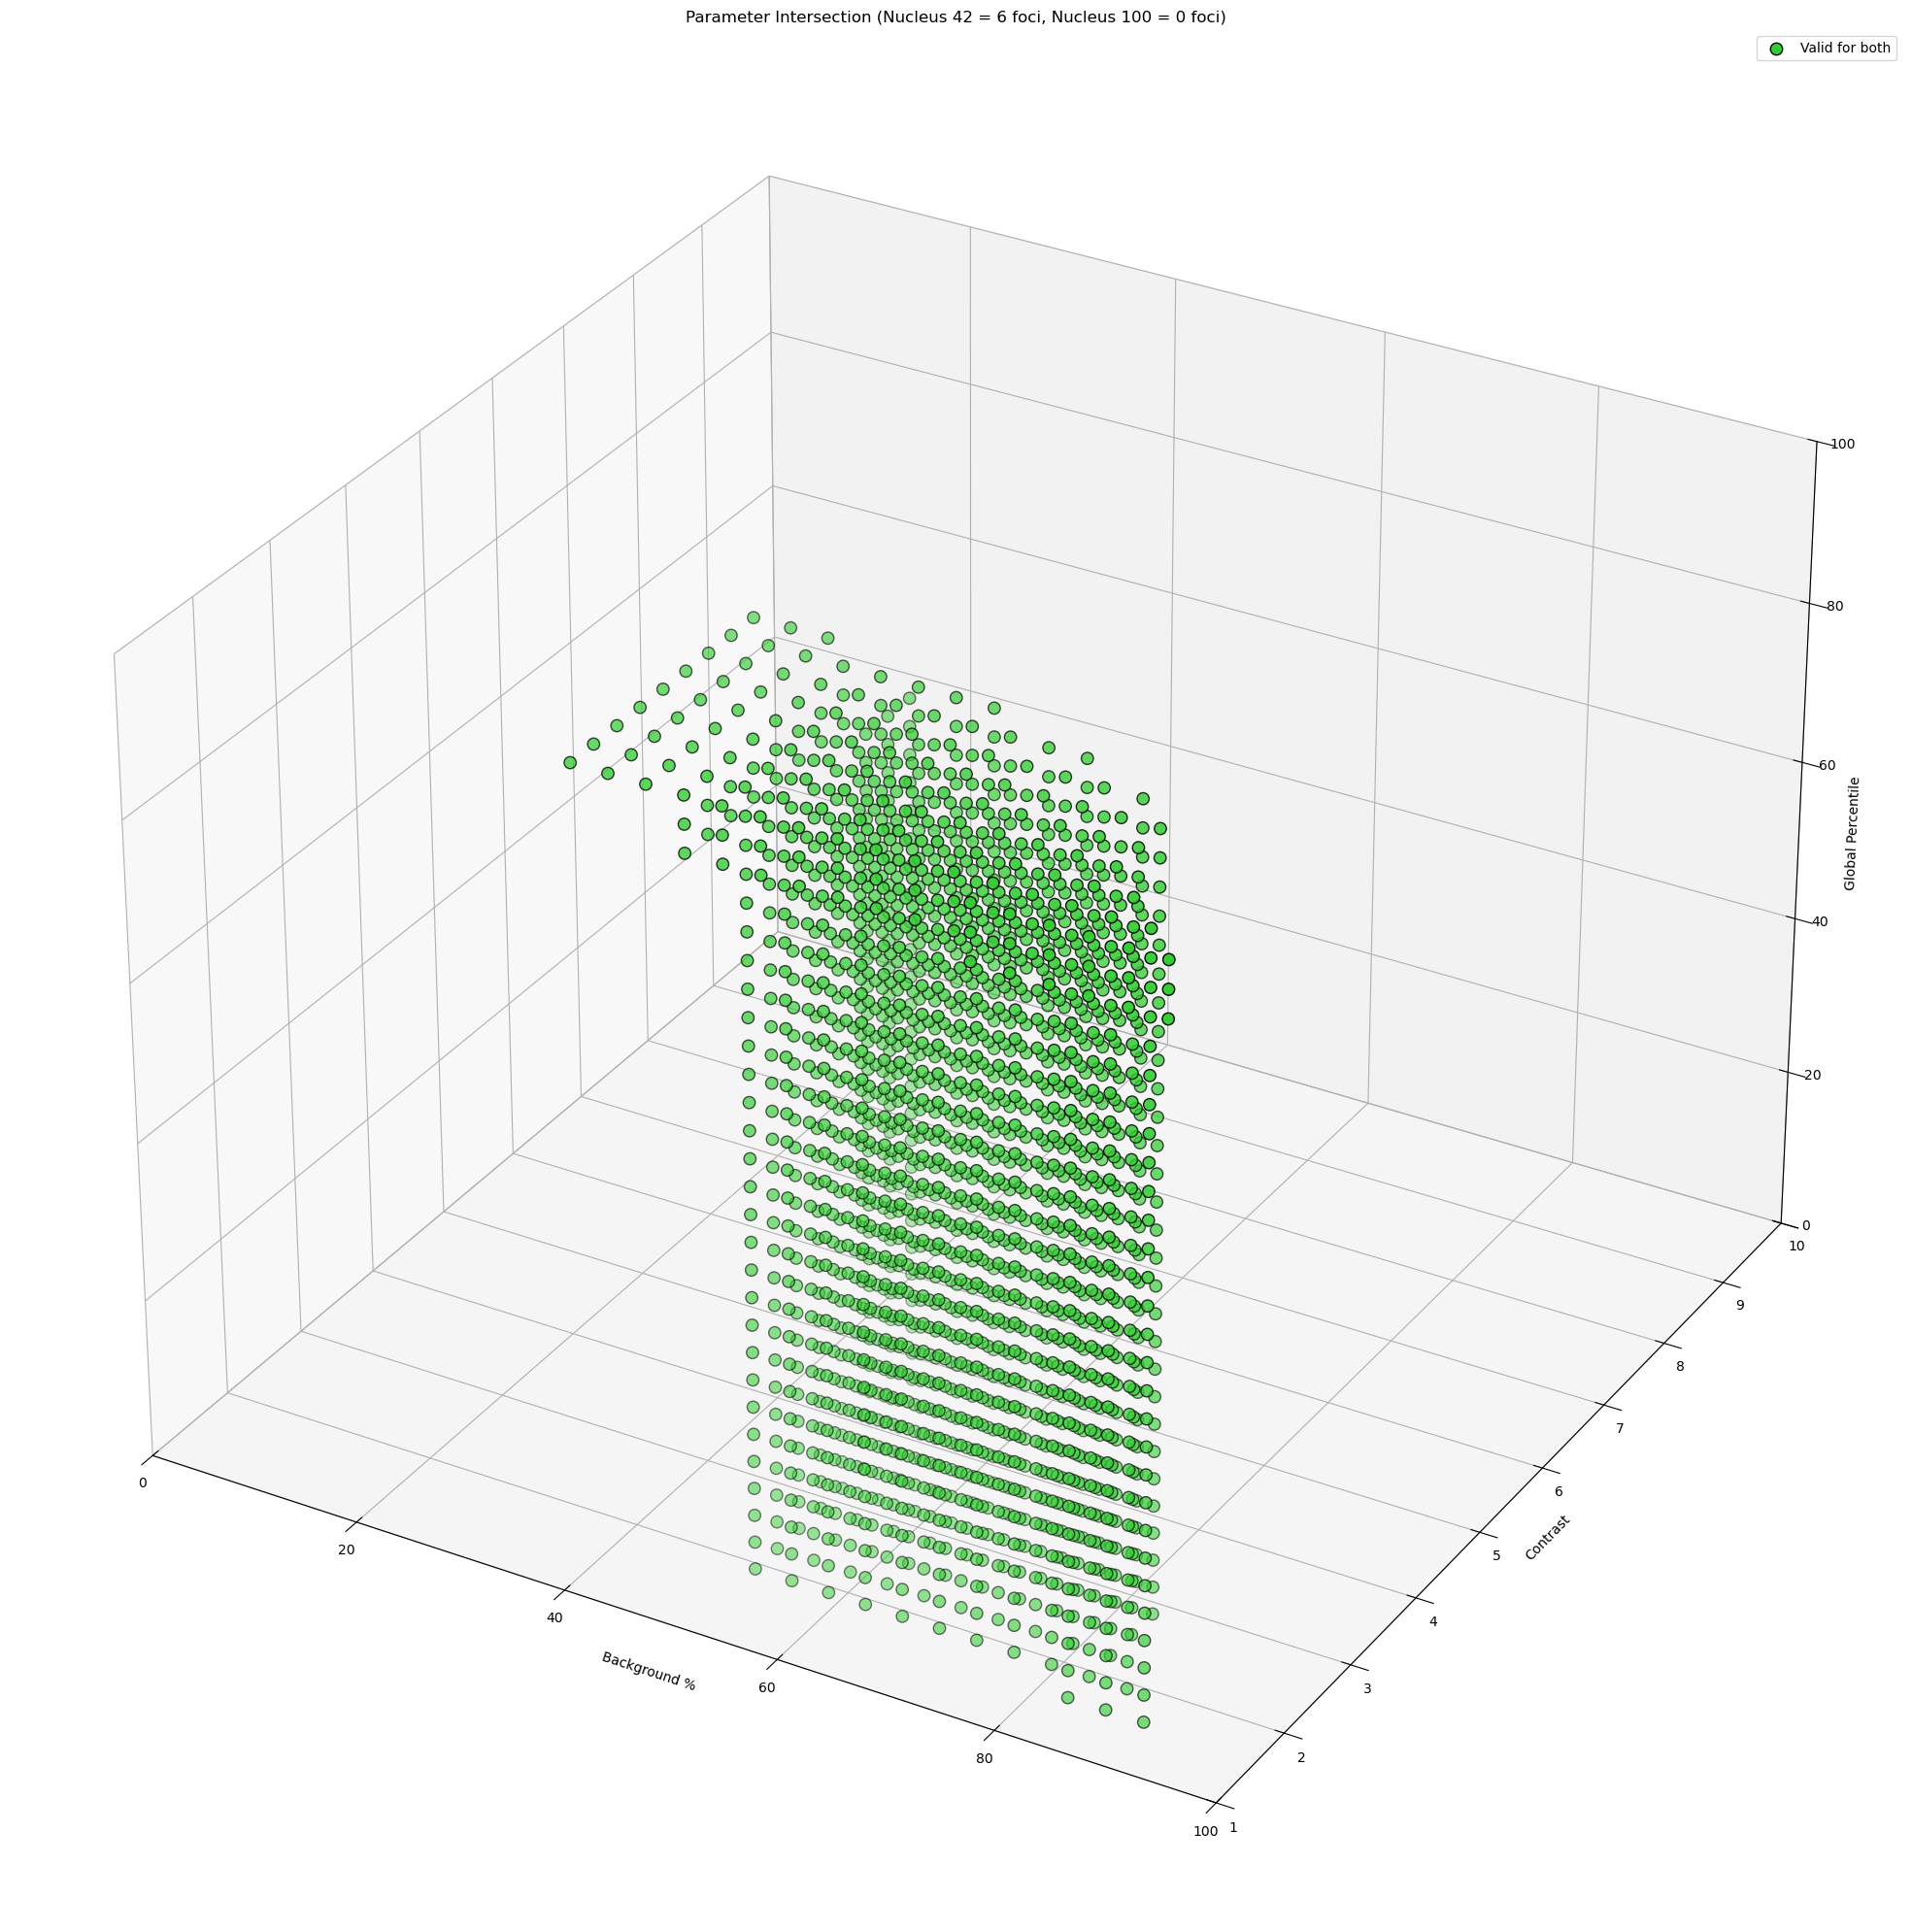

In [11]:
#Combining the Data fro mthe two nuclei and only showing the points that are valid for both
true_counts = {42: 6, 100: 0}
valid_params_42 = parameter_results_df[
    (parameter_results_df["cell_num"] == 42) &
    (parameter_results_df["foci_count"] == true_counts[42])
]

valid_params_100 = parameter_results_df[
    (parameter_results_df["cell_num"] == 100) &
    (parameter_results_df["foci_count"] == true_counts[100])
]
merged_valid = pd.merge(
    valid_params_42,
    valid_params_100,
    on=["bright_pct", "contrast_thresh", "percentile_val"],
    suffixes=("_42", "_100")
)

fig = plt.figure(figsize=(200,20))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    merged_valid["bright_pct"],
    merged_valid["contrast_thresh"],
    merged_valid["percentile_val"],
    color="limegreen",
    s=80,
    edgecolor="k", label='Valid for both'
)
ax = plt.gca()
ax.set_xlim([0, 100])
ax.set_ylim([1, 10])
ax.set_zlim([0,100])
ax.set_xlabel("Background %")
ax.set_ylabel("Contrast")
ax.set_zlabel("Global Percentile")
plt.legend()
plt.title("Parameter Intersection (Nucleus 42 = 6 foci, Nucleus 100 = 0 foci)")
plt.tight_layout()
plt.show()

In [54]:
# 3D KDE Isosurface Solution ...For now
import numpy as np
import open3d as o3d
from scipy.stats import gaussian_kde
from skimage import measure



points_scaled = (points - points.mean(axis=0)) / points.std(axis=0)
# Assuming your 3D parameter points are stored as a NumPy array:
# points = parameter_results_df[["bright_pct", "contrast_thresh", "percentile_val"]].values

# --- Step 1: Fit the KDE ---
kde = gaussian_kde(points.T, bw_method=0.3)  # try values between 0.15–0.4

# --- Step 2: Create a grid over your parameter space ---
grid_x, grid_y, grid_z = np.mgrid[
    points[:, 0].min():points[:, 0].max():50j,
    points[:, 1].min():points[:, 1].max():50j,
    points[:, 2].min():points[:, 2].max():50j
]
coords = np.vstack([grid_x.ravel(), grid_y.ravel(), grid_z.ravel()])

# --- Step 3: Evaluate the KDE density on the grid ---
density = kde(coords).reshape(grid_x.shape)

# --- Step 4: Extract isosurface using Marching Cubes ---
# level controls how "tight" the surface fits — try 70–90 percentile
iso_level = np.percentile(density, 74)
verts, faces, _, _ = measure.marching_cubes(density, level=iso_level)

# Convert grid coordinates back to original data scale
verts_scaled = np.zeros_like(verts)
verts_scaled[:, 0] = np.interp(verts[:, 0], [0, 50], [points[:, 0].min(), points[:, 0].max()])
verts_scaled[:, 1] = np.interp(verts[:, 1], [0, 50], [points[:, 1].min(), points[:, 1].max()])
verts_scaled[:, 2] = np.interp(verts[:, 2], [0, 50], [points[:, 2].min(), points[:, 2].max()])

# --- Step 5: Create Open3D mesh from the surface ---
mesh = o3d.geometry.TriangleMesh(
    o3d.utility.Vector3dVector(verts_scaled),
    o3d.utility.Vector3iVector(faces)
)
mesh.compute_vertex_normals()
mesh.paint_uniform_color([0.7, 0.7, 1.0])  # light blue mesh

# --- Step 6: Create a point cloud for your actual parameter points ---
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.paint_uniform_color([0.1, 0.8, 0.1])  # green points

# --- Step 7: Visualize both together ---
o3d.visualization.draw_geometries([mesh, pcd])

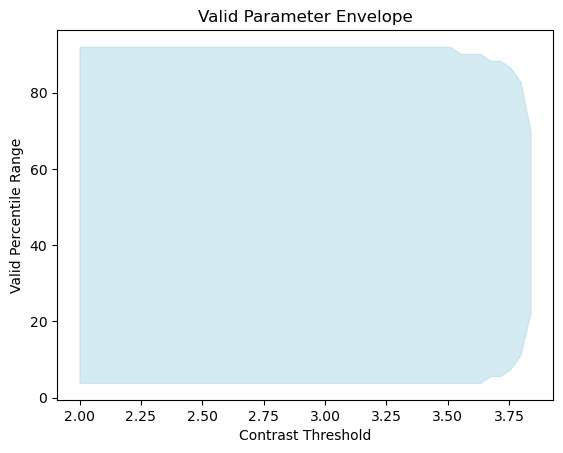

In [57]:
#Convex Hull around the isosurface points
from scipy.spatial import ConvexHull
from scipy.spatial import Delaunay
import pandas as pd

hull = ConvexHull(verts_scaled)

delaunay = Delaunay(verts_scaled)
def in_hull(p):
    return delaunay.find_simplex(p) >= 0

bright_lin = np.linspace(param_ranges["bright_pct"][0], param_ranges["bright_pct"][1], 50)
contrast_lin = np.linspace(param_ranges["contrast_thresh"][0], param_ranges["contrast_thresh"][1], 50)
percent_lin = np.linspace(param_ranges["percentile_val"][0], param_ranges["percentile_val"][1], 50)

grid = np.array(np.meshgrid(bright_lin, contrast_lin, percent_lin)).T.reshape(-1, 3)
inside_mask = in_hull(grid)
inside_points = grid[inside_mask]

df_inside = pd.DataFrame(inside_points, columns=["bright_pct", "contrast_thresh", "percentile_val"])
valid_range_by_contrast = df_inside.groupby("contrast_thresh")["percentile_val"].agg(["min", "max"]).reset_index()

#Visualization
import matplotlib.pyplot as plt

plt.fill_between(valid_range_by_contrast["contrast_thresh"],
                 valid_range_by_contrast["min"],
                 valid_range_by_contrast["max"],
                 color="lightblue", alpha=0.5)
plt.xlabel("Contrast Threshold")
plt.ylabel("Valid Percentile Range")
plt.title("Valid Parameter Envelope")
plt.show()

In [59]:
# Simple bounding box (outer limits)
param_bounds = {
    "bright_pct": (df_inside["bright_pct"].min(), df_inside["bright_pct"].max()),
    "contrast_thresh": (df_inside["contrast_thresh"].min(), df_inside["contrast_thresh"].max()),
    "percentile_val": (df_inside["percentile_val"].min(), df_inside["percentile_val"].max())
}
print(param_bounds)

{'bright_pct': (np.float64(51.0), np.float64(85.53061224489795)), 'contrast_thresh': (np.float64(2.0), np.float64(3.836734693877551)), 'percentile_val': (np.float64(3.836734693877551), np.float64(92.0))}


In [60]:
# Saving the delaunay triangulation and the bounding box of the parameters
import pickle

# Save the Delaunay or ConvexHull object
with open(r"Y:\Group Members\Valentin Aubry\01_Data\Parameters\Hull\valid_parameter_hull.pkl", "wb") as f:
    pickle.dump(delaunay, f)
np.savez(r"Y:\Group Members\Valentin Aubry\01_Data\Parameters\Hull\parameter_bounds.npz", **param_bounds)

In [13]:
pip install open3d 

  Using cached zipp-3.23.0-py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/69.2 MB ? eta -:--:--
   -------------- ------------------------- 24.9/69.2 MB 143.3 MB/s eta 0:00:01
   -------------------------------- ------- 56.6/69.2 MB 150.3 MB/s eta 0:00:01
   ---------------------------------------  68.9/69.2 MB 146.4 MB/s eta 0:00:01
   ---------------------------------------  68.9/69.2 MB 146.4 MB/s eta 0:00:01
   ---------------------------------------  68.9/69.2 MB 146.4 MB/s eta 0:00:01
   ---------------------------------------  68.9/69.2 MB 146.4 MB/s eta 0:00:01
   ---------------------------------------  68.9/69.2 MB 146.4 MB/s eta 0:00:01
   ---------------------------------------  68.9/69.2 MB 146.4 MB/s eta 0:00:01
   ---------------------------------------  68.9/69.2 MB 146.4 MB/s eta 0:00:01
   ---------------------------------------  68.9/69.2 MB 146.4 MB/s eta 0:00:01
   ---------------------------------------  68.9/69.2 MB 146.4 MB/s 

In [23]:
#Very nice representation of the points in 3D --> Mesh didnt work very well
#Alphashape mesh

import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt

points = np.array(merged_valid[['bright_pct', 'contrast_thresh', 'percentile_val']])

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

alpha = 5  # adjust
mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(pcd, alpha)

# Visualize interactively
o3d.visualization.draw_geometries([mesh, pcd])

[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh
[Open3D WARNING] [CreateFromPointCloudAlphaShape] invalid tetra in TetraMesh

In [9]:
pip install scikit-learn

  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   ----

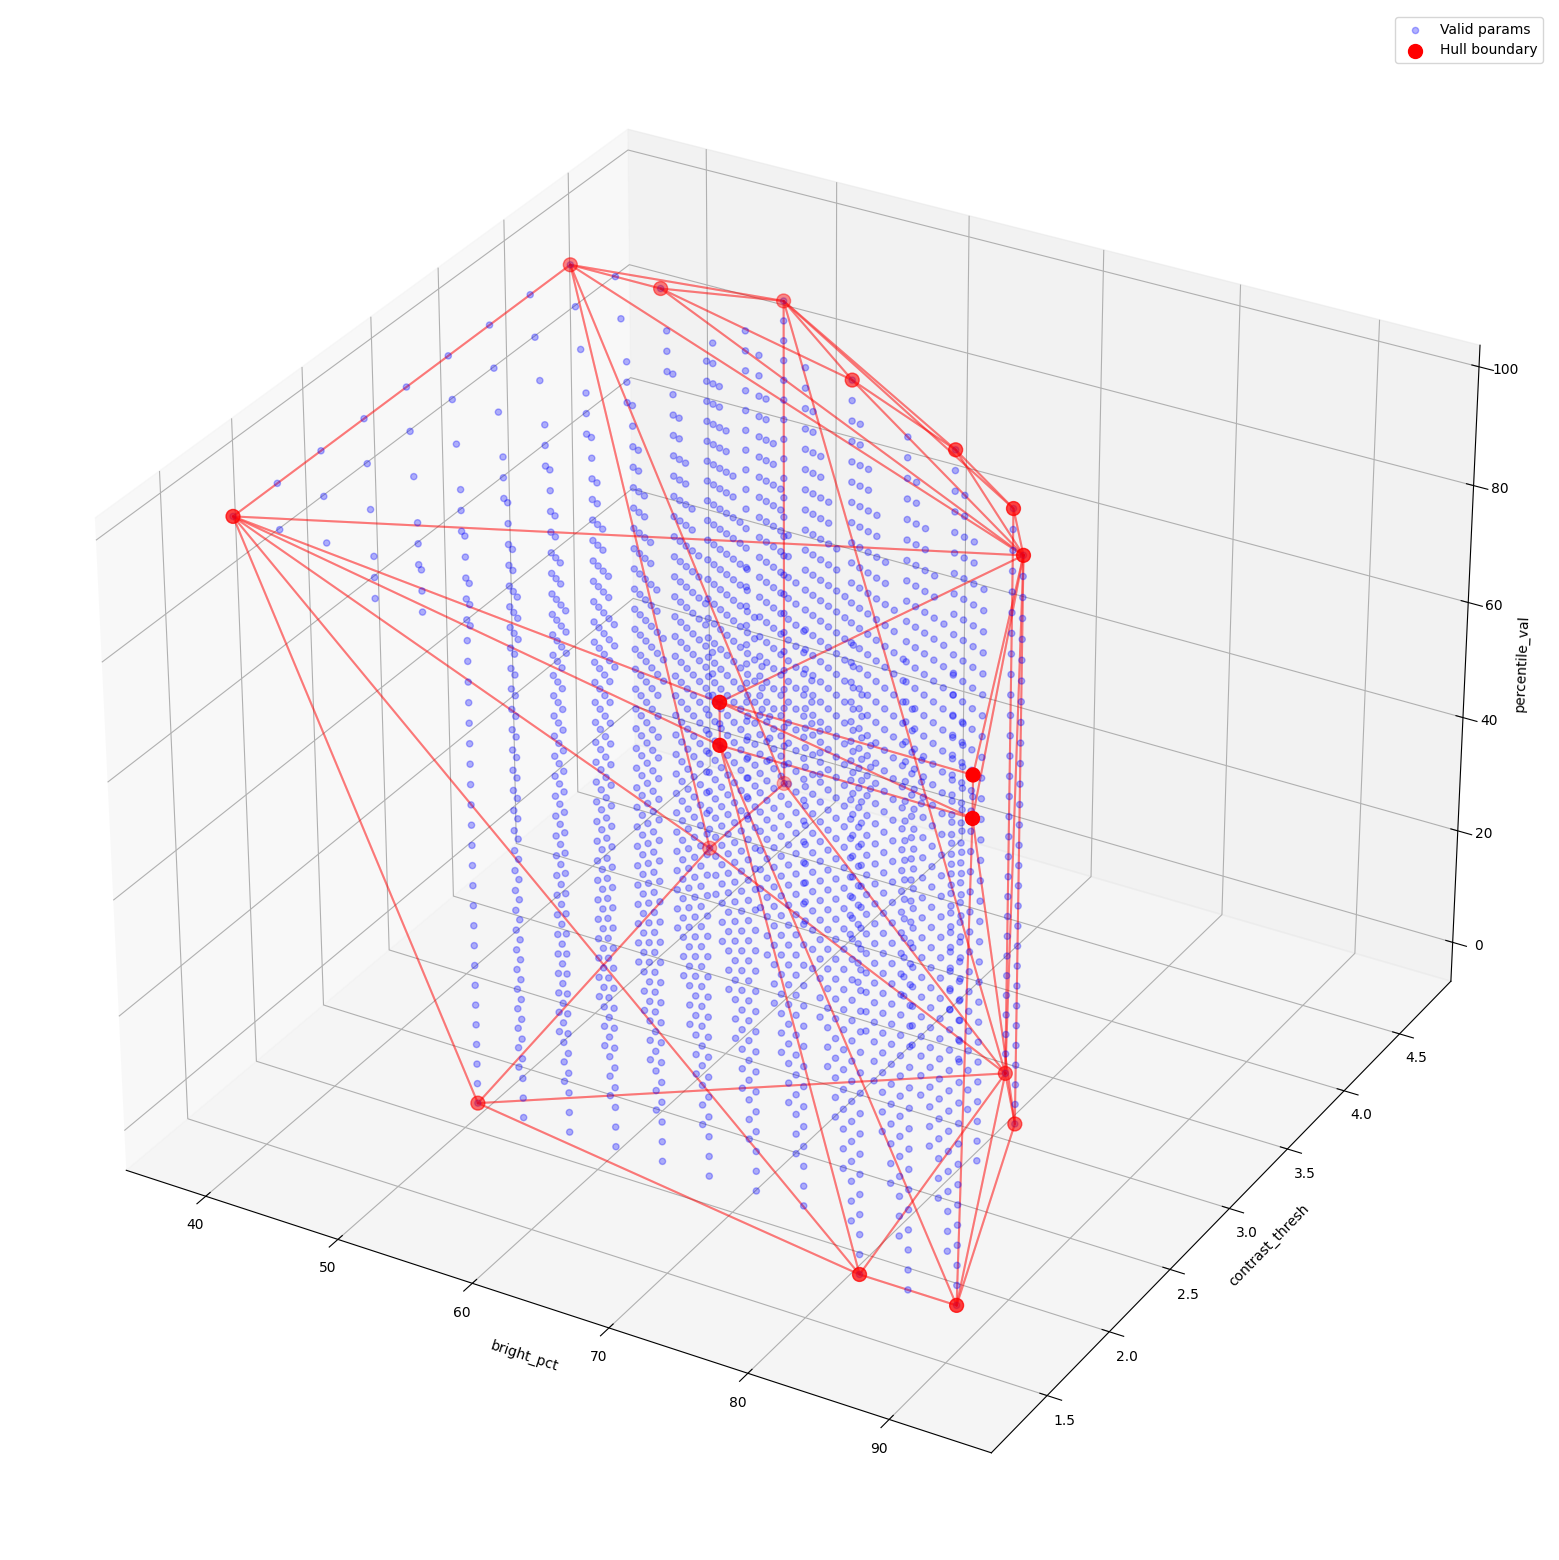

In [42]:
#Trying the convex hull approach to define boundaries
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(200, 20))
ax = fig.add_subplot(111, projection='3d')

# Plot all valid points
ax.scatter(points[:, 0], points[:, 1], points[:, 2], c='blue', alpha=0.3, label='Valid params')

# Plot hull vertices
hull_points = points[hull.vertices]
ax.scatter(hull_points[:, 0], hull_points[:, 1], hull_points[:, 2], 
           c='red', s=100, label='Hull boundary')

# Draw hull edges
for simplex in hull.simplices:
    simplex = np.append(simplex, simplex[0])  # close the loop
    ax.plot(points[simplex, 0], points[simplex, 1], points[simplex, 2], 'r-', alpha=0.3)

ax.set_xlabel('bright_pct')
ax.set_ylabel('contrast_thresh')
ax.set_zlabel('percentile_val')
ax.legend()
plt.show()

In [36]:
#Simple parameter range percentiles (Box shape)
low_quant = np.linspace(0.00, 0.5, 11)
high_quant = np.linspace(1, 0.5, 11)

for i in range(11):
    param1_range = (round(float(merged_valid['bright_pct'].quantile(low_quant[i])),2), round(float(merged_valid['bright_pct'].quantile(high_quant[i])),2))
    param2_range = (round(float(merged_valid['contrast_thresh'].quantile(low_quant[i])),2), round(float(merged_valid['contrast_thresh'].quantile(high_quant[i])),2))
    param3_range = (round(float(merged_valid['percentile_val'].quantile(low_quant[i])),2), round(float(merged_valid['percentile_val'].quantile(high_quant[i])),2))
    
    print(f"{i}-----{round(low_quant[i],2)} + {round(high_quant[i],2)}----Percentiles------------------\nBackground brightness: {param1_range}\nContrast threshold: {param2_range}\nMinimal foci brightness: {param3_range}")

0-----0.0 + 1.0----Percentiles------------------
Background brightness: (37.93, 93.1)
Contrast threshold: (1.31, 4.72)
Minimal foci brightness: (0.0, 96.55)
1-----0.05 + 0.95----Percentiles------------------
Background brightness: (48.28, 82.76)
Contrast threshold: (1.62, 3.79)
Minimal foci brightness: (3.45, 96.55)
2-----0.1 + 0.9----Percentiles------------------
Background brightness: (51.72, 82.76)
Contrast threshold: (1.93, 3.51)
Minimal foci brightness: (10.34, 89.66)
3-----0.15 + 0.85----Percentiles------------------
Background brightness: (51.72, 79.31)
Contrast threshold: (1.93, 3.48)
Minimal foci brightness: (13.79, 86.21)
4-----0.2 + 0.8----Percentiles------------------
Background brightness: (55.17, 75.86)
Contrast threshold: (1.93, 3.48)
Minimal foci brightness: (20.69, 82.76)
5-----0.25 + 0.75----Percentiles------------------
Background brightness: (55.17, 75.86)
Contrast threshold: (2.24, 3.17)
Minimal foci brightness: (24.14, 75.86)
6-----0.3 + 0.7----Percentiles--------

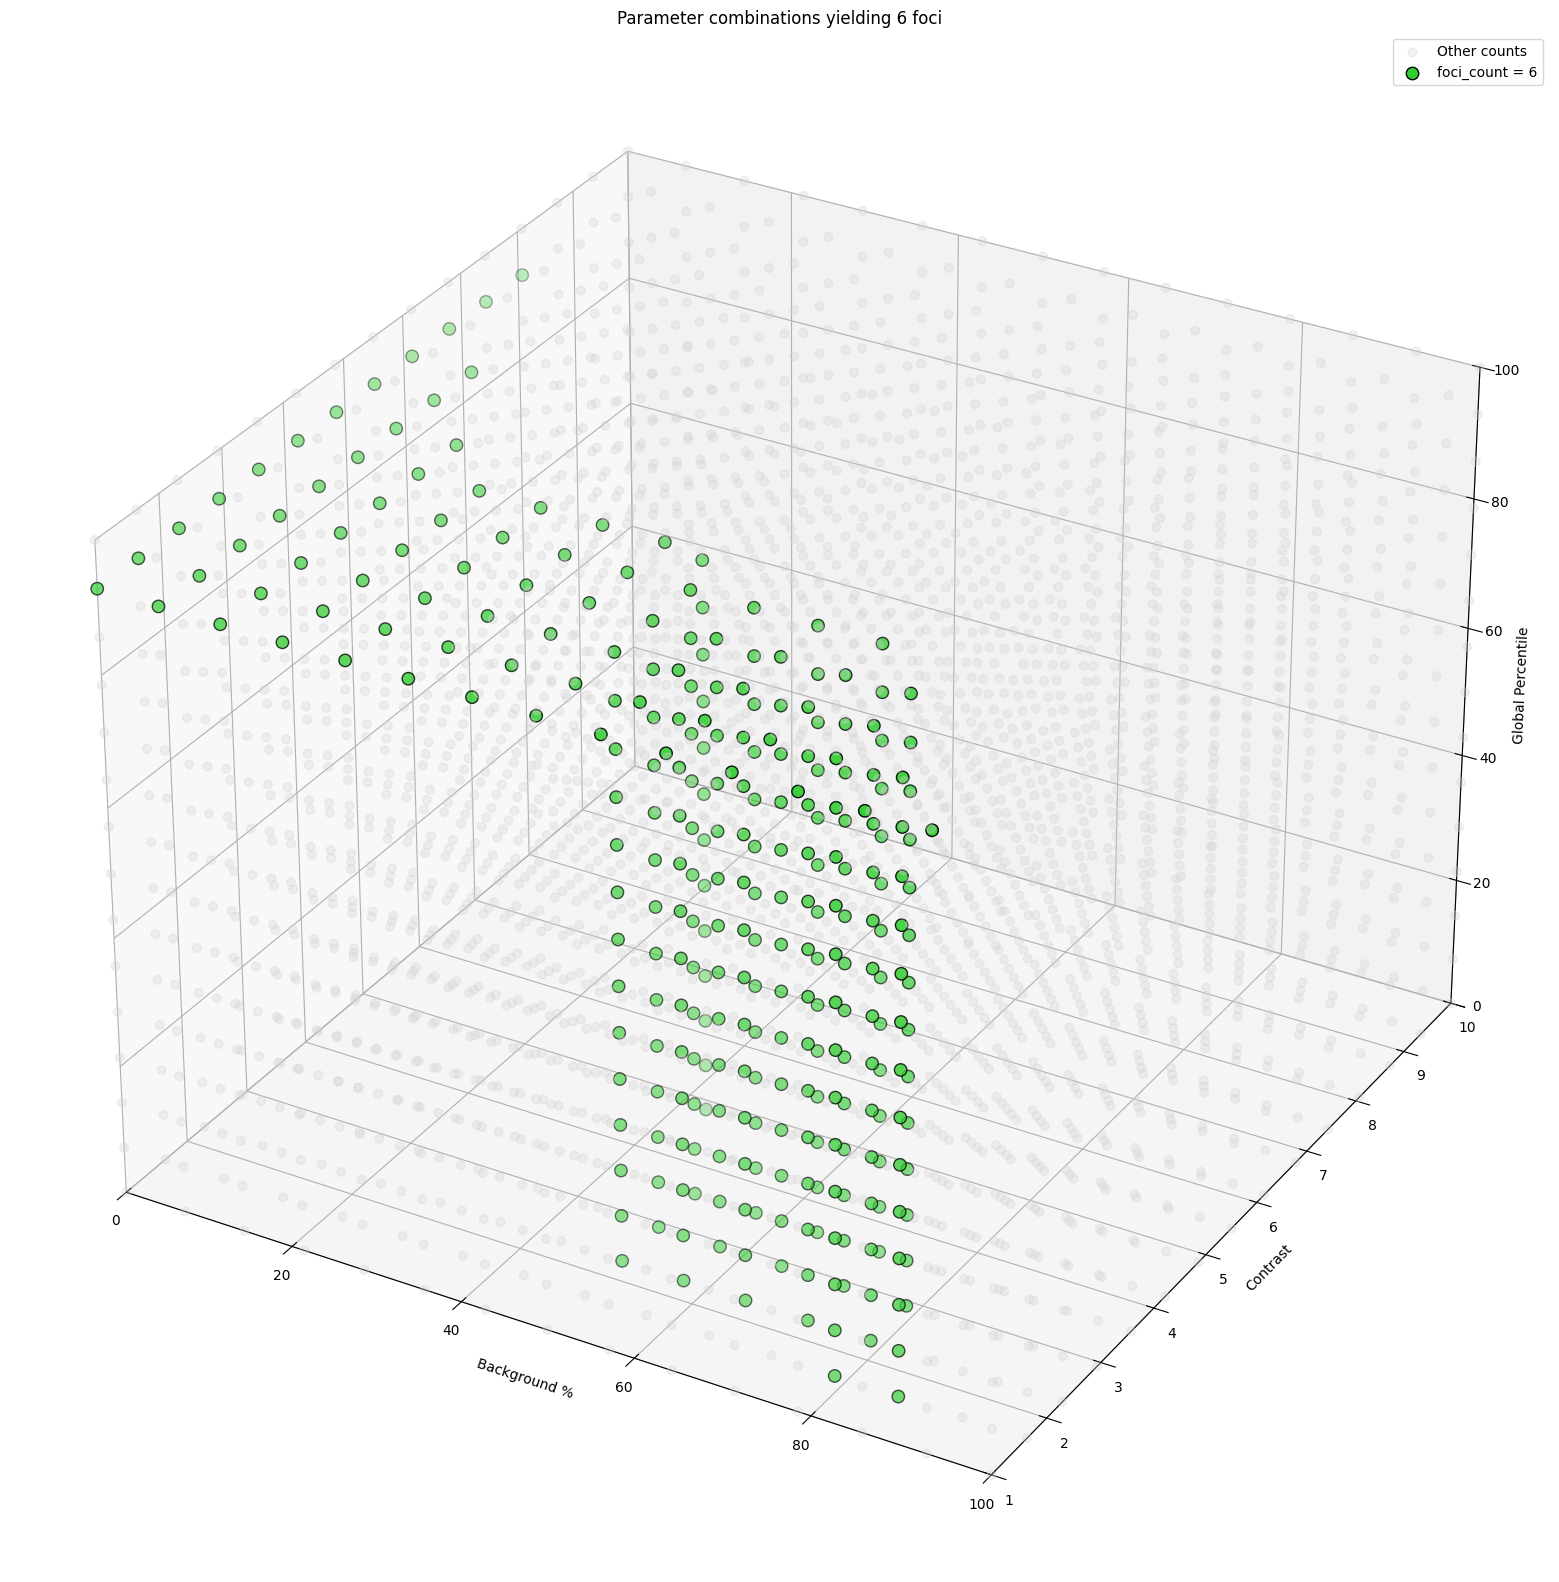

In [15]:
subset_6 = parameter_results_df[parameter_results_df["foci_count"] == 6]
subset_other = parameter_results_df[parameter_results_df["foci_count"] != 6]

fig = plt.figure(figsize=(200,20))
ax = fig.add_subplot(111, projection='3d')

# All other points (gray, semi-transparent)
ax.scatter(
    subset_other["bright_pct"],
    subset_other["contrast_thresh"],
    subset_other["percentile_val"],
    color="lightgray",
    alpha=0.3,
    s=40,
    label="Other counts"
)

# Highlighted points (green, opaque)
ax.scatter(
    subset_6["bright_pct"],
    subset_6["contrast_thresh"],
    subset_6["percentile_val"],
    color="limegreen",
    s=80,
    edgecolor="k",
    label="foci_count = 6"
)
ax = plt.gca()
ax.set_xlim([0, 100])
ax.set_ylim([1, 10])
ax.set_zlim([0,100])
ax.set_xlabel("Background %")
ax.set_ylabel("Contrast")
ax.set_zlabel("Global Percentile")
ax.legend()
plt.title("Parameter combinations yielding 6 foci")
plt.show()

In [7]:
print(len(nums))

112


In [15]:
print(os.path.basename(TRITC_data[0]))

ATR2_24h--W00044--P00021--Z00000--T00000--TRITC SEM.tif


In [ ]:
# 5--> 58, 75, 93, 37

In [14]:
print(len(np.unique(masks)))

113


In [5]:
picture_number = 0
cell_number = 10


#High Throughput Data Loading Loop
#for i in range (len(DAPI_data)):
i = picture_number

#Loading the picture on i position from each channel
Cy5_pic = imageio.imread(Cy5_data[i])
DAPI_pic = imageio.imread(DAPI_data[i])
DAPI_mask_pic = np.load(DAPI_mask_data[i], allow_pickle=True)
FITC_pic = imageio.imread(FITC_data[i])
TRITC_pic = imageio.imread(TRITC_data[i])

TRITC_pic = img_as_float(TRITC_pic)




almost_max = np.percentile(TRITC_pic[TRITC_pic > 0], 99) # Gets the brightness of the 99th percentile of brightest pixels to reduce outliers

foci_distance_filt = 2
foci_threshold_filt = almost_max * 0.8

foci_distance_unfilt = 2
foci_threshold_unfilt = almost_max * 0.8

tolerance = 2  # Distance at which the detected foci in the gamma adjusted TRIC picture are confirmed if there is one also detected on the DoG picture




# Extract the name of the picture that will be analyzed to later be able to save it accordingly
base_name = os.path.basename(DAPI_data[i]).removesuffix('DAPI SEM.tif')

# Extract the actual mask array
masks = DAPI_mask_pic  # This contains the segmented regions

# Function to generate a picture for every cell that cellpose recognized
#for j in range (1,len(np.unique(masks))):
j = cell_number

# Defining which nucleus from the Segmentation Mask is isolated
cellnumber = j
masks_reduced = (masks == cellnumber)  

# Overlaying DAPI mask to TRITC
masked_TRITC = np.ma.masked_where(masks_reduced == 0, masks_reduced)  




# Applying the mask to the TRITC picture by setting the background to 0 (black)
isolated_TRITC = TRITC_pic.copy()  # copying the original picture so that it doesn't get changed
isolated_TRITC[masks_reduced==False] = 0  # assign the pixels from the TRITC picture copy the value 0 (black), where the mask has the value false (background)

#gamma_TRITC = skimage.exposure.adjust_gamma(isolated_TRITC, gamma=1)
#isolated_TRITC = exposure.rescale_intensity(isolated_TRITC, in_range='image', out_range=(0, isolated_TRITC.max()))


# Applying a difference of gaussian filter on the picture --> enhances peaks and smooths out background
filtered_TRITC = skimage.filters.difference_of_gaussians(isolated_TRITC, low_sigma=1, high_sigma=2, mode='nearest', cval=0, channel_axis=None, truncate=4.0)
filtered_TRITC = np.clip(filtered_TRITC, 0, None)

#filtered_TRITC = skimage.exposure.adjust_gamma(filtered_TRITC, gamma=1)
filtered_TRITC = exposure.rescale_intensity(filtered_TRITC, in_range='image', out_range=(0, isolated_TRITC.max()))


# Detecting the coordinates of the peaks in the unfiltered picture
coordinates_filtered = peak_local_max(
    filtered_TRITC, 
    min_distance=foci_distance_filt,        # This is just the minimal distance of how close two foci can be detected next to eachother
    threshold_abs=foci_threshold_filt       # Only peaks above X% of absolute brightest picture (not relative to the brightest pixel in the picture)
)

# Detecting the coordinates of the peaks in the filtered picture
coordinates_unfiltered = peak_local_max(
    isolated_TRITC, 
    min_distance=foci_distance_unfilt,        # This is just the minimal distance of how close two foci can be detected next to eachother
    threshold_abs=foci_threshold_unfilt       # Only peaks above X% of absolute brightest picture (not relative to the brightest pixel in the picture)
)

def local_contrast(image, coordinates, bright_percentage, contrast_threshold=2.5):
    confirmed_coords = []  #Empty array to store the filtered coordinates in later
    for i in coordinates:
        y, x = i   # Get the coordinates for each foci 
        y_min, y_max = max(0, y-6), min(image.shape[0], y+7)  #setting boudaries from y-5 to y+5(Y+6 gets excluded as upper border)
        x_min, x_max = max(0, x-6), min(image.shape[1], x+7)
        square = image[y_min:y_max, x_min:x_max]  #creating a square with the defined boudaries

        potential_foci = image[y, x]
        local_background = np.percentile(square, bright_percentage)  # Selects a pixel with the brightness in the defined percentage for comparison

        if potential_foci > local_background * contrast_threshold:  # If the potential foci is X-times brighter than the selected background, the foci is confirmed
            confirmed_coords.append(i)
            
    # returns the confirmed foci coordinates or if there are none creates an empty array to not crash the display below
    return np.array(confirmed_coords) if confirmed_coords else np.array([]).reshape(0, 2)
    
# Running the above defined function on the filtered and unfiltered coordinates
coordinates_unfiltered = local_contrast(isolated_TRITC, coordinates_unfiltered, 52.5, contrast_threshold=1.75)
coordinates_filtered = local_contrast(filtered_TRITC, coordinates_filtered, 52.5, contrast_threshold=1.75)


# Find foci that are close in both sets (within tolerance distance)
distances = cdist(coordinates_unfiltered, coordinates_filtered)  # calculate the distance between filtered foci and unfiltered foci
tolerance = tolerance  # pixels of how far apart the foci maximally can be on both pictures to be confirmed


if coordinates_unfiltered.size > 0 and coordinates_filtered.size > 0:
    # Keep foci from unfiltered that have a match in filtered
    coordinates = coordinates_unfiltered[np.min(distances, axis=1) <= tolerance]  # np.min: find minimal distance between nearest foci, 
    #<=tolerance: creates a boolean array with true for each unfiltered foci with a filtered one within tolerance, 
    #coordinates_unfiltered[]: keeps only foci that are True
else:
    coordinates = np.array([]).reshape(0, 2)  #generating an epmty array, so that the visualization down below doesn't get an error if no foci was detected






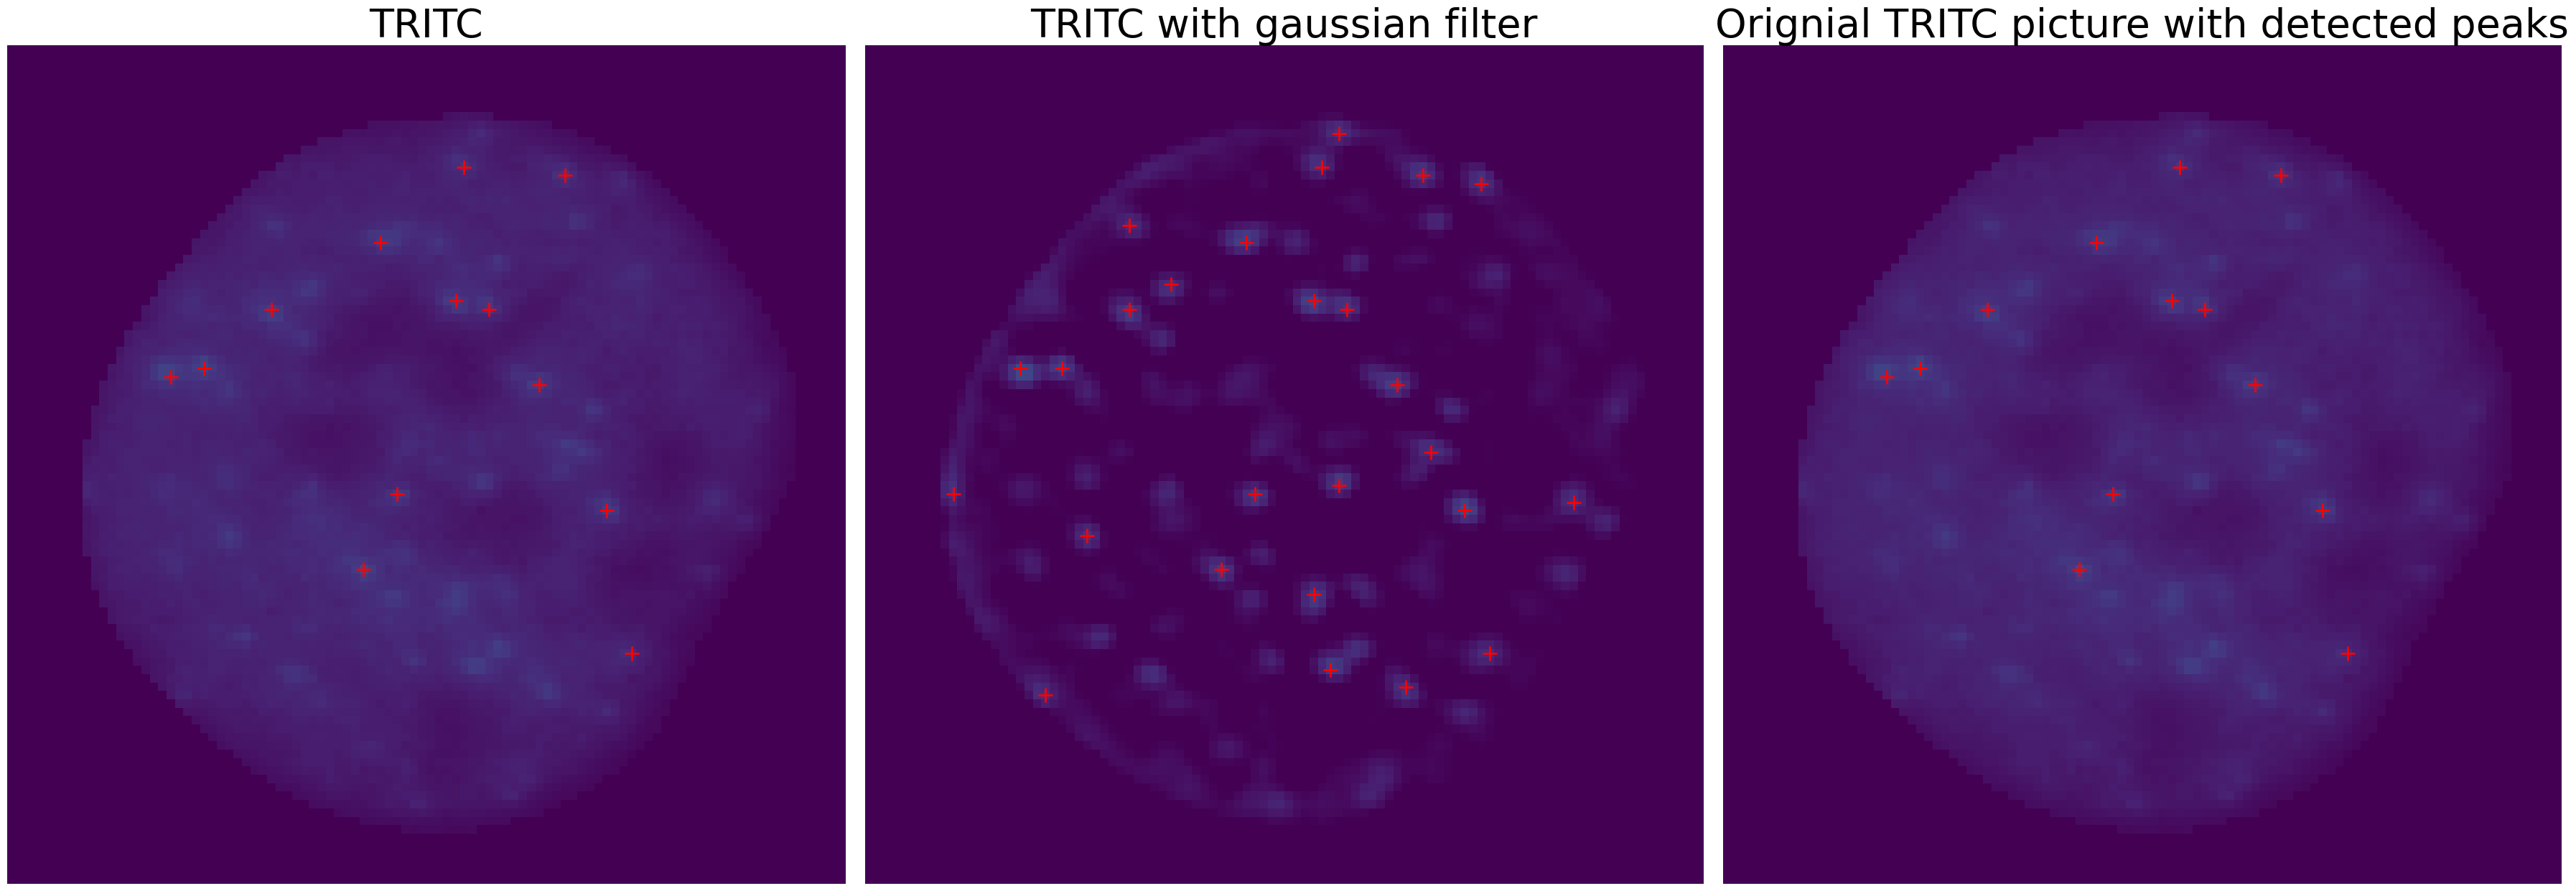

In [6]:
# Displaying the original picture with an isolated cell and the filtered picture
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(36, 12))

# Finding the middle coordinates for the cell we want to look at
props = regionprops(masks_reduced.astype(int))  # Calculate region properties (centroid, area, etc.) for the cell mask
if props:  # Check if any regions (props) were found in the mask
    centroid_y, centroid_x = props[0].centroid  # Extract y and x coordinates of the cell's center, which is the only region (props[0])

# To stop the possibility of going out of boundary
if int(centroid_y) < 50:
    centroid_y = 50
if int(centroid_x) < 50:
    centroid_x = 50

# Initial crop
origin = ((int(centroid_y)-50),(int(centroid_x)-50))
#origin = (0,0)
size = (100,100) #~100x100 for single cell
#size = (2048,2048)


# Original TRITC Picture with isolated cell
axes[0].imshow(isolated_TRITC[origin[0]:origin[0]+size[0],origin[1]:origin[1]+size[1]], vmin=0, vmax=TRITC_pic.max())

####################### Made by AI ###################################
# Adjust coordinates relative to the cropped region
adjusted_unfiltered = coordinates_unfiltered - origin
# Filter to only show peaks within the cropped region
mask = (adjusted_unfiltered[:, 0] >= 0) & (adjusted_unfiltered[:, 0] < size[0]) & \
       (adjusted_unfiltered[:, 1] >= 0) & (adjusted_unfiltered[:, 1] < size[1])
visible_unfiltered = adjusted_unfiltered[mask]

# Plot the peaks
axes[0].plot(visible_unfiltered[:, 1], visible_unfiltered[:, 0], 'r+', 
             markersize=15, markeredgewidth=2)
#####################################################################

axes[0].axis('off')
axes[0].set_title('TRITC', fontsize = 40)

# Filtered TRITC picture with isolated cell
axes[1].imshow(filtered_TRITC[origin[0]:origin[0]+size[0],origin[1]:origin[1]+size[1]], vmin=0, vmax=TRITC_pic.max()) 

####################### Made by AI ###################################
# Adjust coordinates relative to the cropped region
adjusted_filtered = coordinates_filtered - origin
# Filter to only show peaks within the cropped region
mask = (adjusted_filtered[:, 0] >= 0) & (adjusted_filtered[:, 0] < size[0]) & \
       (adjusted_filtered[:, 1] >= 0) & (adjusted_filtered[:, 1] < size[1])
visible_filtered = adjusted_filtered[mask]

# Plot the peaks
axes[1].plot(visible_filtered[:, 1], visible_filtered[:, 0], 'r+', 
             markersize=15, markeredgewidth=2)
#####################################################################

axes[1].axis('off')
axes[1].set_title('TRITC with gaussian filter', fontsize = 40)

# Original TRITC Picture with isolated cell
axes[2].imshow(isolated_TRITC[origin[0]:origin[0]+size[0],origin[1]:origin[1]+size[1]], vmin=0, vmax=TRITC_pic.max())

####################### Made by AI ###################################
# Adjust coordinates relative to the cropped region
adjusted_coords = coordinates - origin
# Filter to only show peaks within the cropped region
mask = (adjusted_coords[:, 0] >= 0) & (adjusted_coords[:, 0] < size[0]) & \
       (adjusted_coords[:, 1] >= 0) & (adjusted_coords[:, 1] < size[1])
visible_coords = adjusted_coords[mask]

# Plot the peaks
axes[2].plot(visible_coords[:, 1], visible_coords[:, 0], 'r+', 
             markersize=15, markeredgewidth=2)
#####################################################################

axes[2].axis('off')
axes[2].set_title('Orignial TRITC picture with detected peaks', fontsize = 40)

plt.tight_layout()
plt.show()

In [22]:
#Watershed Segmentation on DoG filtered TRITC Picture with the detected peaks as starting points
water_threshold = foci_threshold_filt

markers = np.zeros_like(filtered_TRITC, dtype=int)  # creates an array with the same shape and size as isolated_TRITC but all zeros
for i, (x, y) in enumerate(coordinates, start=1):  
    markers[x, y] = i  # gives the previously created zero array a number at the point of the foci coordinates

# Use original markers without dilation - watershed will keep them separate
#markers_expanded = markers.copy()


# One of these 
distance = ndi.distance_transform_edt(filtered_TRITC < water_threshold)  # calculates Distance to the nearest background
gradient = sobel(filtered_TRITC)


# Ensure all marker positions are included in the mask
watershed_mask = (filtered_TRITC > water_threshold) | (markers > 0)

# Creates a mask that contains all the pixels that would get segmented in the watershed and the pixel that was detected as the center of the foci
water_labels = watershed(gradient, markers, mask=watershed_mask)  # Applying Watershed, -distance to invert map height map (to make peaks to valleys)
# The watershed was now done within the borders of the previously defined mask


# To get all the data from the watershed
for region_id in range(1, markers.max() + 1):
    spot_mask = (water_labels == region_id)
    spot_area = np.sum(spot_mask)
    spot_intensity = np.sum(isolated_TRITC[spot_mask])





In [3]:
#Watershed Segmentation with the help of blob_dog
TRITC_blob = blob_dog(isolated_TRITC, min_sigma=1, max_sigma=2, threshold=foci_threshold_filt*0.003)

# Creates an arry with the same size as the picture filled with zeros
markers = np.zeros_like(isolated_TRITC, dtype=int)

# Creates a Mask with the detected blobs as starting regions
#for i, (by, bx, sigma) in enumerate(TRITC_blob, start=1): # Gives each blob an individual number i
for i, (by, bx) in enumerate(coordinates, start=1): # Gives each blob an individual number i
    # Get sigma from blob_dog if available, otherwise use default
    if i-1 < len(TRITC_blob):
        sigma = TRITC_blob[i-1][2]  # Extract sigma from corresponding blob
    else:
        sigma = 1.5  # Default sigma if blob_dog didn't detect enough blobs
    
    print(f"Coordinate {i}: ({by}, {bx}), sigma: {sigma}")

    
    rr, cc = np.ogrid[:isolated_TRITC.shape[0], :isolated_TRITC.shape[1]] # Creates 2 arrays rr and cc with the same size as the picture for indexing
    mask = (rr - by)**2 + (cc - bx)**2 <= (sigma * 1.5)**2 # Creates Mask where all the blob regions are True (radius proportional to blobsize)
    markers[mask] = i # All blob regions get a unique number i

# Creates an elevation map where edges (high change in intensity) are high and flat regions (low/no change in intensity) are low
elevation_map = sobel(isolated_TRITC)

blob_labels = segmentation.watershed(elevation_map, markers) # Does the watershed segmentation with the elevation map as base and the markers(previously defined blob regions) for starting 

NameError: name 'blob_dog' is not defined

<function matplotlib.pyplot.show(close=None, block=None)>

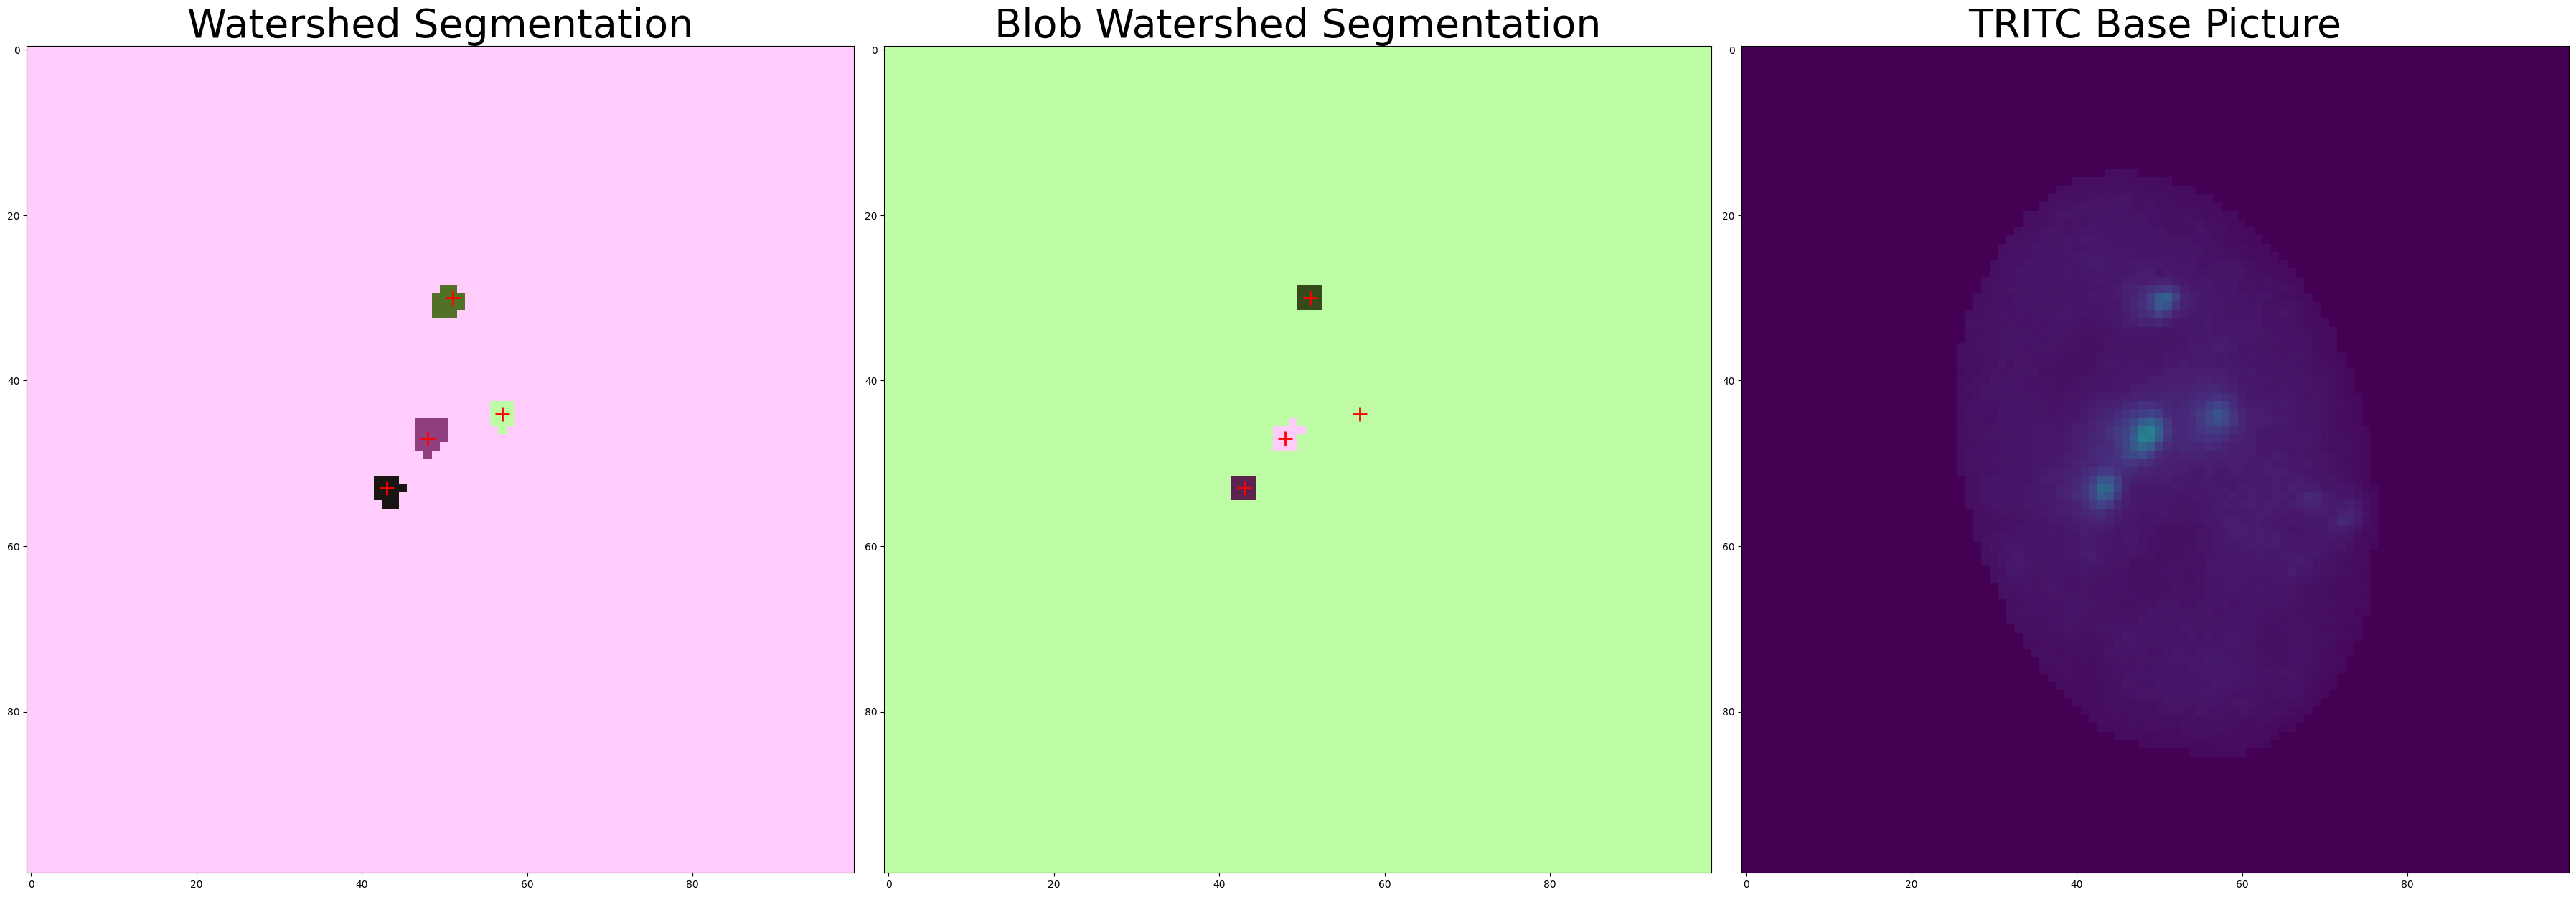

In [26]:
# Displaying the original picture with an isolated cell and the filtered picture
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(36, 12))

# Finding the middle coordinates for the cell we want to look at
props = regionprops(masks_reduced.astype(int))  # Calculate region properties (centroid, area, etc.) for the cell mask
if props:  # Check if any regions (props) were found in the mask
    centroid_y, centroid_x = props[0].centroid  # Extract y and x coordinates of the cell's center, which is the only region (props[0])

# To stop the possibility of going out of boundary
if int(centroid_y) < 50:
    centroid_y = 50
if int(centroid_x) < 50:
    centroid_x = 50

# Initial crop
origin = ((int(centroid_y)-50),(int(centroid_x)-50))
#origin = (0,0)
size = (100,100) #~100x100 for single cell
#size = (2048,2048)






# Show the watershed labels as colored regions
axes[0].imshow(water_labels[origin[0]:origin[0]+size[0],origin[1]:origin[1]+size[1]], cmap = 'vanimo')

####################### Made by AI ###################################
# Adjust coordinates relative to the cropped region
adjusted = coordinates - origin
# Filter to only show peaks within the cropped region
mask = (adjusted[:, 0] >= 0) & (adjusted[:, 0] < size[0]) & \
       (adjusted[:, 1] >= 0) & (adjusted[:, 1] < size[1])
visible = adjusted[mask]

# Plot the peaks
axes[0].plot(visible[:, 1], visible[:, 0], 'r+', 
             markersize=15, markeredgewidth=2)
#####################################################################

axes[0].set_title('Watershed Segmentation', fontsize = 40)



# Show the watershed labels as colored regions
axes[1].imshow(blob_labels[origin[0]:origin[0]+size[0],origin[1]:origin[1]+size[1]], cmap = 'vanimo')

####################### Made by AI ###################################
# Adjust coordinates relative to the cropped region
adjusted = coordinates - origin
# Filter to only show peaks within the cropped region
mask = (adjusted[:, 0] >= 0) & (adjusted[:, 0] < size[0]) & \
       (adjusted[:, 1] >= 0) & (adjusted[:, 1] < size[1])
visible = adjusted[mask]

# Plot the peaks
axes[1].plot(visible[:, 1], visible[:, 0], 'r+', 
             markersize=15, markeredgewidth=2)
#####################################################################

axes[1].set_title('Blob Watershed Segmentation', fontsize = 40)


axes[2].imshow(isolated_TRITC[origin[0]:origin[0]+size[0],origin[1]:origin[1]+size[1]], vmin=0, vmax=TRITC_pic.max())
axes[2].set_title('TRITC Base Picture', fontsize = 40)

plt.tight_layout()
plt.show

Text(0.5, 1.0, 'DAPI')

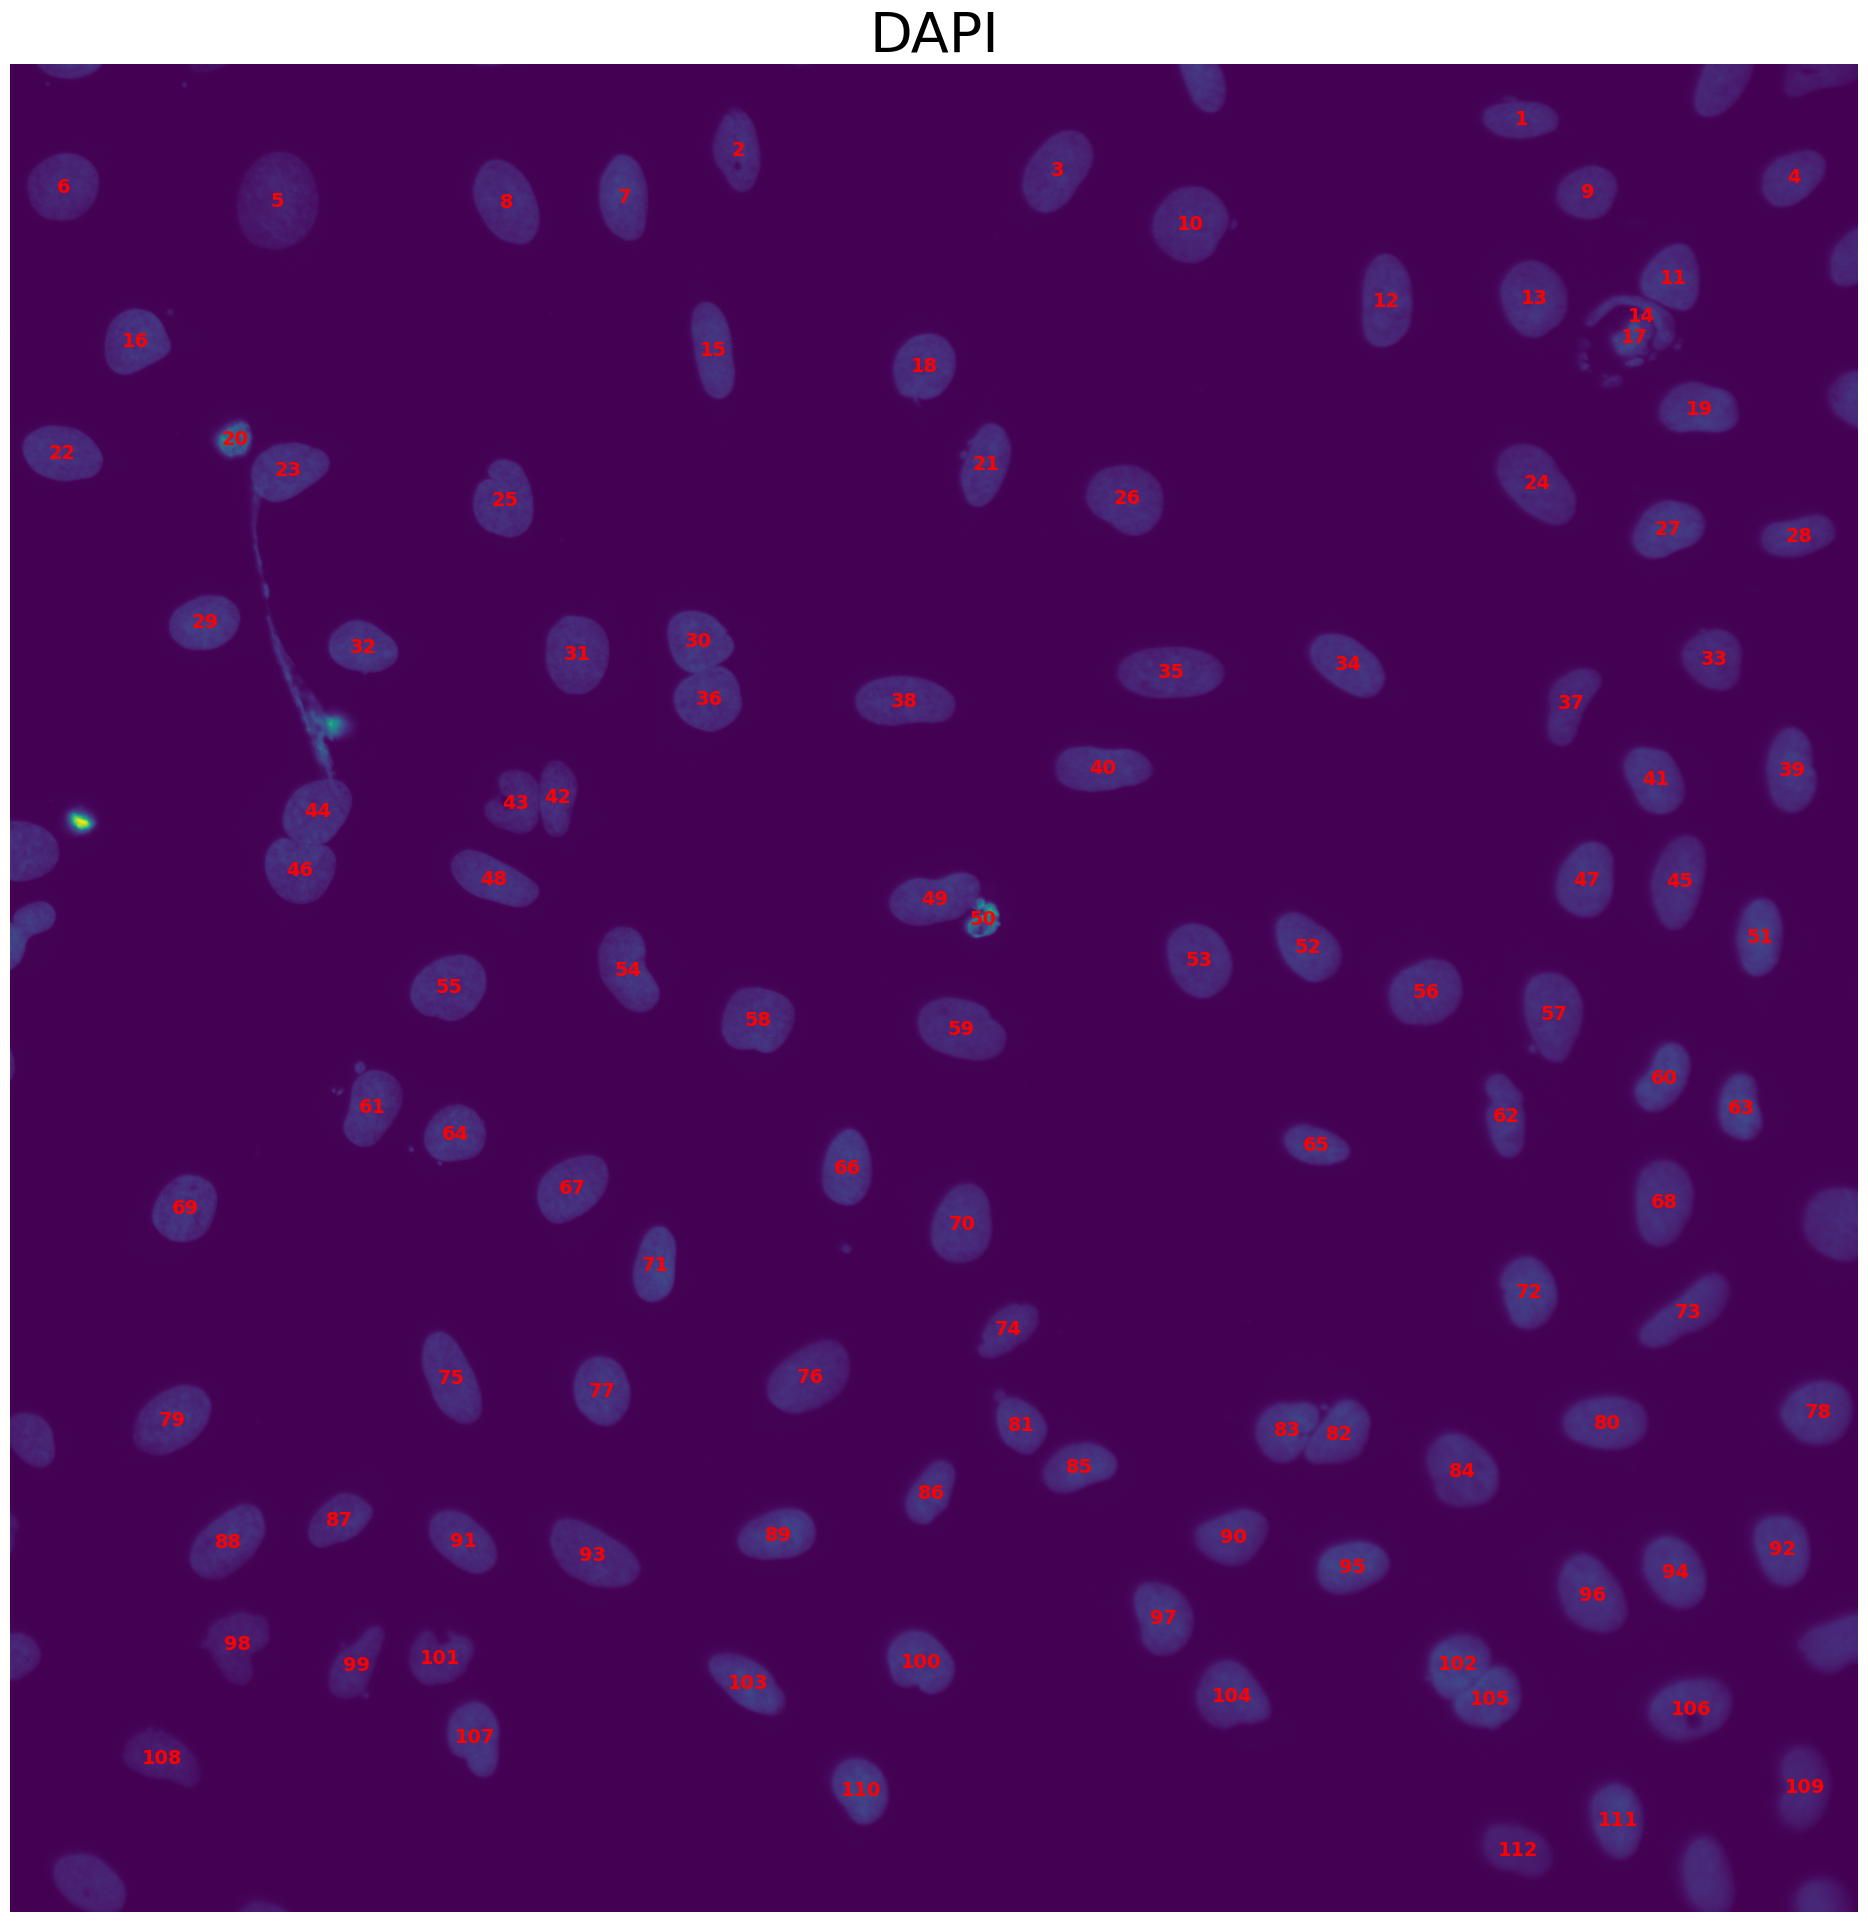

In [10]:
# Plotting Masks
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(36, 24))

# Original DAPI Picture
axes.imshow(DAPI_pic)

# Adding numbers to the Individual nuclei to identify them easier
nums = regionprops(masks)
for prop in nums:
    #Getting the coordinates of the center of the nuclei
    y, x = prop.centroid  # getting the x and y coordinates
    label = prop.label   # getting the number of the nucleus at that position

    # Adding the text at the location of the centroids
    axes.text(x, y, str(label), color = 'red', fontsize = 14, ha = 'center', va = 'center', weight = 'bold')

axes.axis('off')
axes.set_title('DAPI', fontsize = 40)

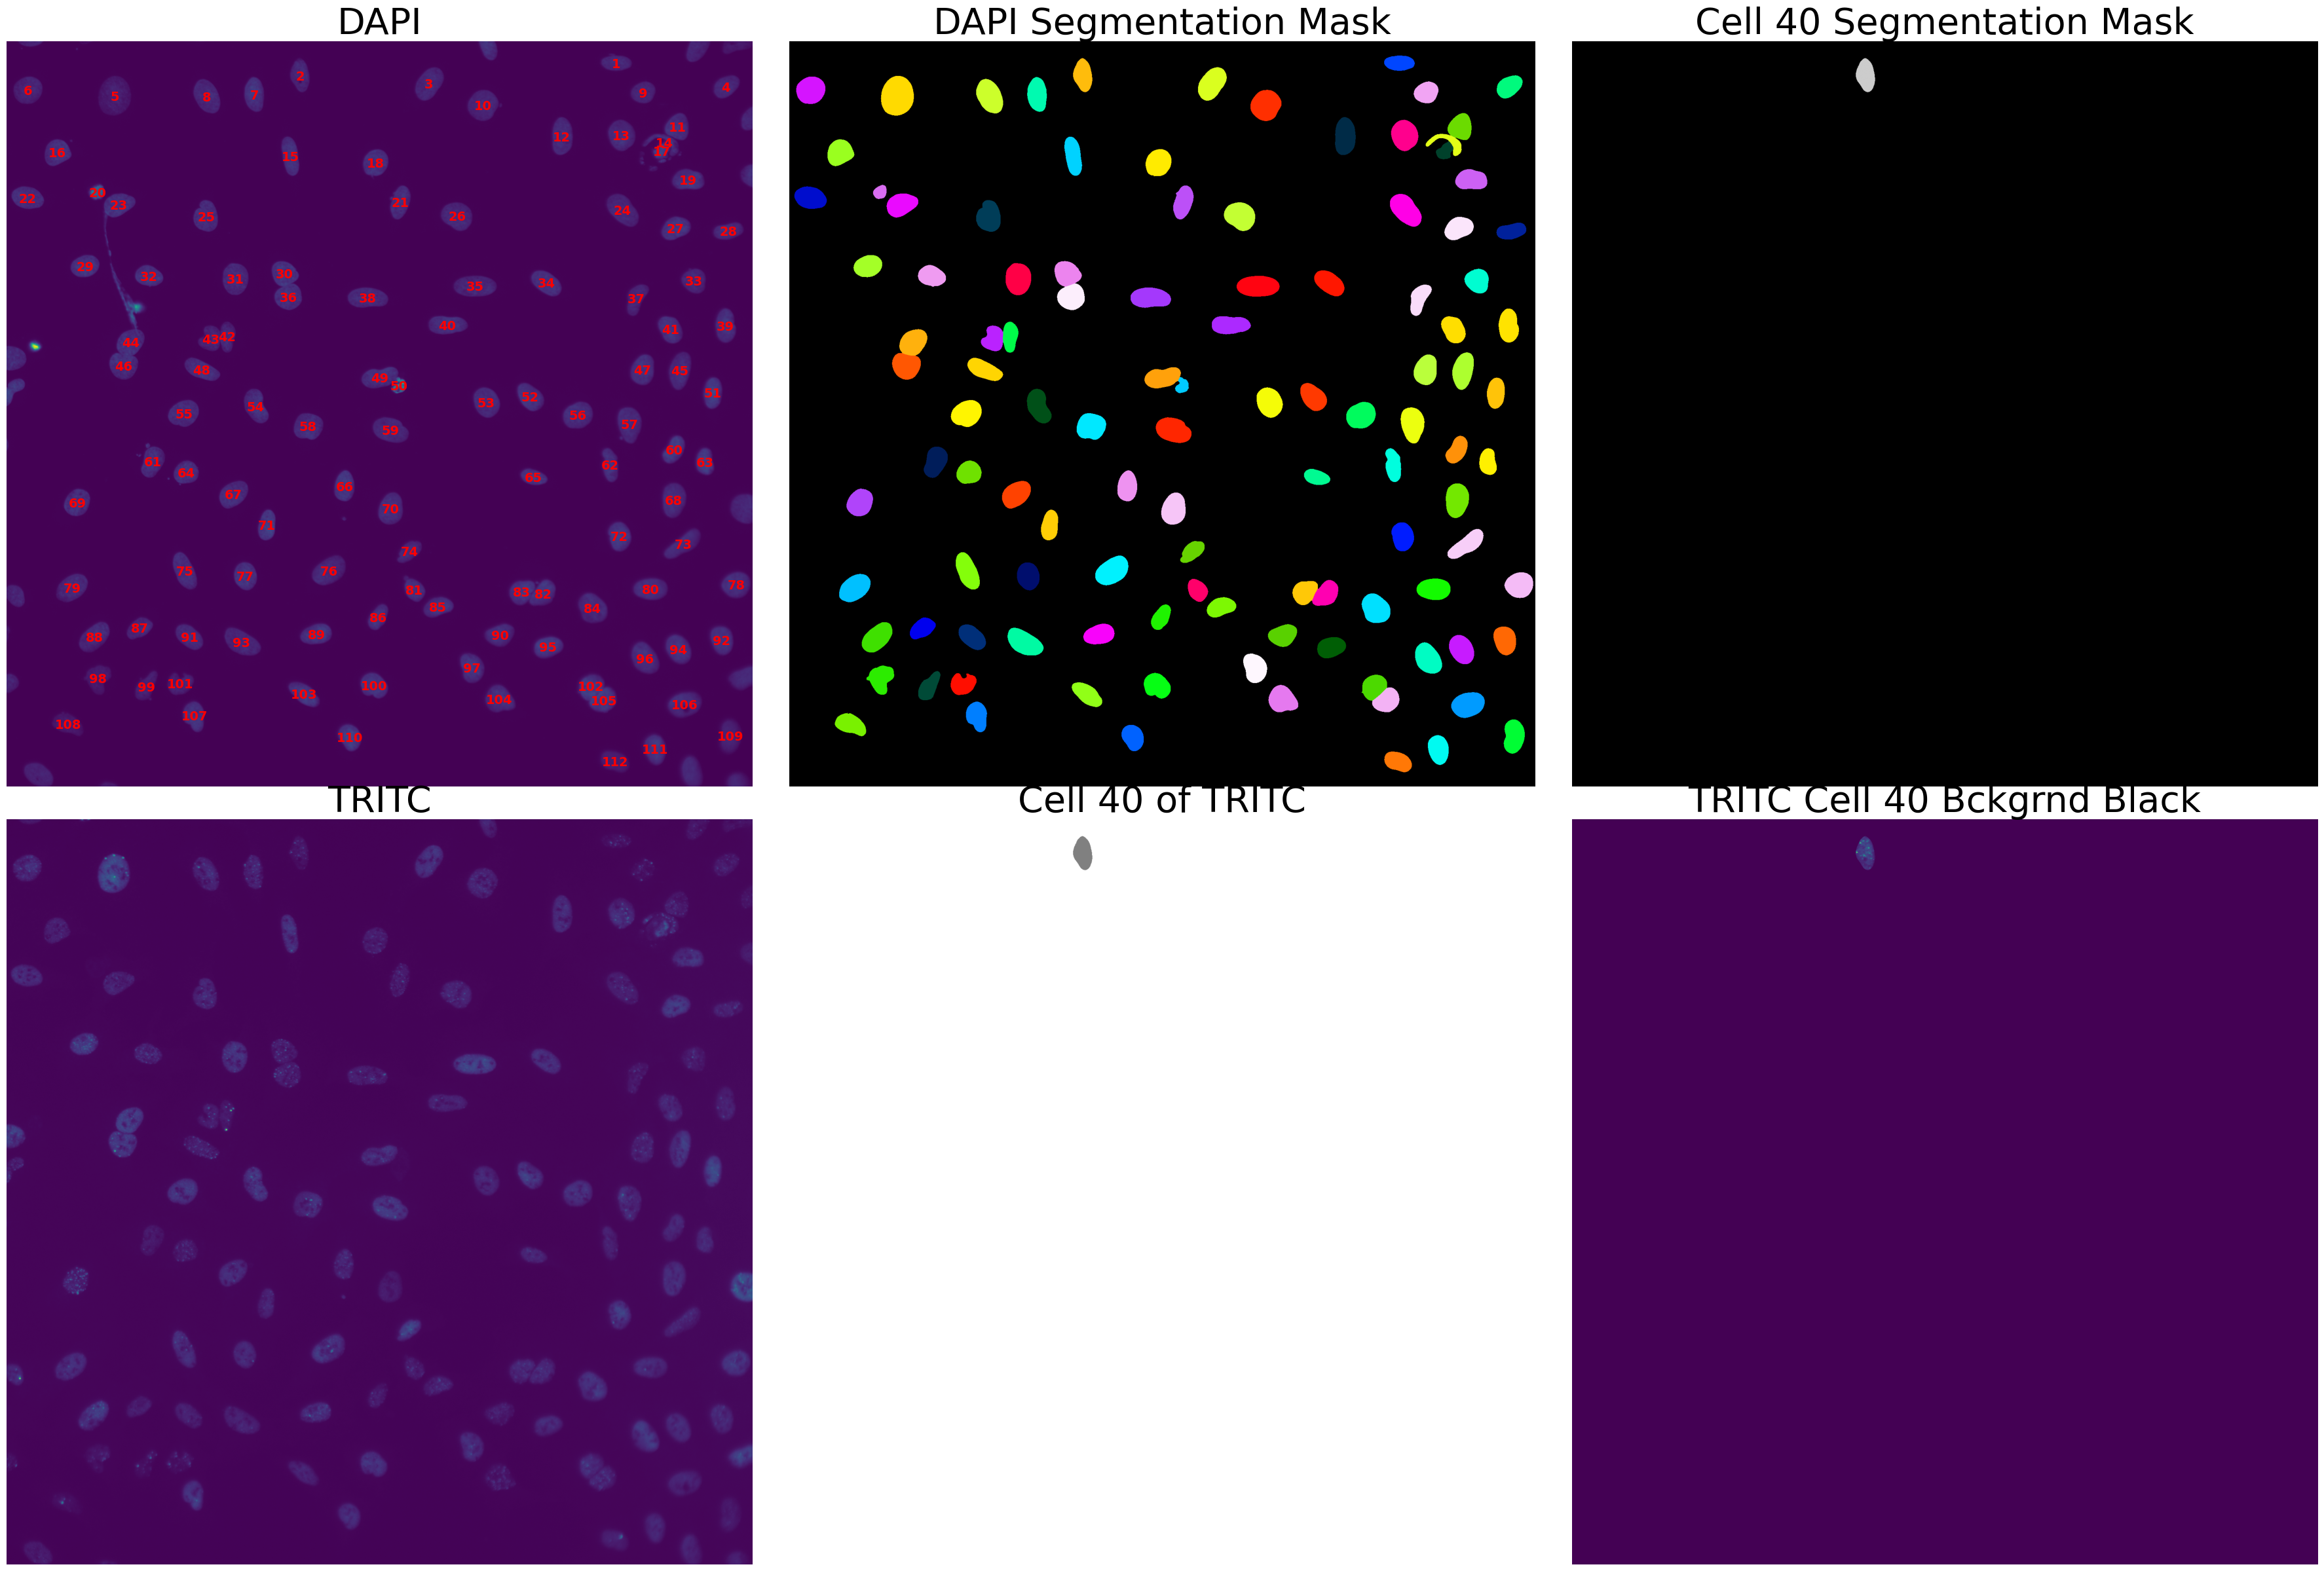

In [54]:
# Plotting Masks
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(36, 24))

# Original DAPI Picture
axes[0,0].imshow(DAPI_pic)

# Adding numbers to the Individual nuclei to identify them easier
nums = regionprops(masks)
for prop in nums:
    #Getting the coordinates of the center of the nuclei
    y, x = prop.centroid  # getting the x and y coordinates
    label = prop.label   # getting the number of the nucleus at that position

    # Adding the text at the location of the centroids
    axes[0,0].text(x, y, str(label), color = 'red', fontsize = 14, ha = 'center', va = 'center', weight = 'bold')

axes[0,0].axis('off')
axes[0,0].set_title('DAPI', fontsize = 40)

# Create a shuffled colormap to randomize colors
#np.random.seed(37)  # Makes the colors always the same
num_labels = masks.max()  # Gets the highest number from the nuclei to know how many there are

# Generate random colors for each nucleus (so for 150 nuclei there are 150 colors generated +1 for the background)
colors = plt.cm.gist_ncar(np.linspace(0, 1, num_labels + 1))
np.random.shuffle(colors[1:])  # Shuffle all colors starting at 1 except background (index 0)

# Set background to black: colors[0] to black [R=0, G=0, B=0, Alpha=1] so the background is always black
colors[0] = [0, 0, 0, 1]  

# Create custom colormap, listedColormap takes the array of colors and creates a matplotlib colormap object
custom_cmap = ListedColormap(colors)

# Create display mask with proper color indexing
masks_display = masks.copy()
# Normalize to 0-1 range for colormap
axes[0,1].imshow(masks_display, cmap=custom_cmap, vmin=0, vmax=num_labels)
axes[0,1].axis('off')
axes[0,1].set_title('DAPI Segmentation Mask', fontsize=40)

# Singular Nucleus isolated from Mask
axes[0,2].imshow(masks_reduced, cmap='nipy_spectral')
axes[0,2].axis('off')
axes[0,2].set_title('Cell 40 Segmentation Mask', fontsize = 40)

# Original TRITC Picture
axes[1,0].imshow(TRITC_pic)
axes[1,0].axis('off')
axes[1,0].set_title('TRITC', fontsize = 40)

# Mask overlaying the TRITC Picture
axes[1,1].imshow(masked_TRITC, cmap='nipy_spectral', alpha=0.5)
axes[1,1].axis('off')
axes[1,1].set_title('Cell 40 of TRITC', fontsize = 40)

#show TRITC with applied mask
axes[1,2].imshow(isolated_TRITC)
axes[1,2].axis('off')
axes[1,2].set_title('TRITC Cell 40 Bckgrnd Black', fontsize = 40)

plt.tight_layout()
plt.show()